# Residual Scaling × Normalization with a Constant Learning Rate

**Notebook 09 — background execution authorized. Saved outputs below record progress.**

Train at depths **2, 4, 8, 16, 32, and 64**, with **1,000 completed AdamW updates per actual run**, using a constant learning rate of **0.0003** from the first update. There is **no warm-up and no learning-rate decay**.

At each depth compare residual multipliers **1 (unscaled)** and **2/L (scaled)**, with the four normalization variants below. All other settings are shared between the two sides at the same depth. This isolates the residual multiplier under Notebook 08's common initialization, attention scaling, and optimizer-role rules. The unscaled side is therefore **not the original nanoGPT parameterization from Notebook 07**.

| Norm ID | Existing pre-norms and final norm | Extra norm before both W_O and W_2 |
|---|---|---|
| A | LayerNorm | None |
| B | LayerNorm | LayerNorm |
| C | RMSNorm | None |
| D | RMSNorm | RMSNorm |

There are **6 depths × 2 residual settings × 4 norms = 48 comparison entries**, but only **44 actual training runs**. At L=2, 2/L=1, so the four scaled entries explicitly reuse the four unscaled runs, histories, and checkpoints. They are not independent replications.

Run order: L2 unscaled → L2 scaled (reuse) → L4 unscaled → L4 scaled → ... → L64 unscaled → L64 scaled. At every condition, run A/B/C/D in order. Start fresh; checkpoints from Notebooks 07 and 08 cannot be used because their training histories used a different learning-rate schedule.


## Shared architecture and initialization

Character IDs → token + learned absolute position embeddings → dropout → L pre-norm Transformer layers → final norm → tied vocabulary projection → next-character cross-entropy.

Each layer has two residual additions:

1. Pre-norm → QKV → causal attention → concatenate heads → optional extra norm (256 features) → W_O → dropout → multiply by r → add to the residual stream.
2. Pre-norm → W_1 → GELU → optional extra norm (1,024 features) → W_2 → dropout → multiply by r → add to the residual stream.

Here r is 1 or 2/L. The identity branch is unchanged. Both extra norm locations are switched together.

| Setting | Shared value |
|---|---|
| Hidden width / heads / head width | 256 / 4 / 64 |
| MLP expansion / internal width | 4× / 1,024 |
| Context length / vocabulary | 256 / 65 characters |
| Activation / positions | GELU / learned absolute embeddings |
| Dropout | 0.2 during training; off during evaluation |
| Linear and normalization biases | Disabled |
| Token/output embedding weights | Tied; counted once |
| All embedding and hidden weight distributions | Normal with mean 0 and standard deviation 0.02 |
| QKV, W_O, W_1, W_2 initialization std | 0.02 on both sides, at every depth |
| Norm gamma initialization / norm epsilon | Learnable gamma = 1 / epsilon = 1e-5 |
| Attention score multiplier | 1 / head width = 1/64 on both sides |
| Input and training-logit multipliers | 1 on both sides |
| Device / precision | Apple MPS / float32; no compilation or mixed precision |

The 0.02 output-matrix initialization overrides nanoGPT's default 0.02/sqrt(2L). Extra norm scales use constant initialization and do not consume random matrix initialization draws. Within each depth, all actual runs must have identical initial shared matrices; fingerprints are checked before training. Different depths are not required to share identical full matrices.

| Layers | A/C parameters | B/D parameters | Actual runs |
|---:|---:|---:|---:|
| 2 | 1,656,320 | 1,658,880 | 4; scaled entries reuse unscaled |
| 4 | 3,230,208 | 3,235,328 | 8 |
| 8 | 6,377,984 | 6,388,224 | 8 |
| 16 | 12,673,536 | 12,694,016 | 8 |
| 32 | 25,264,640 | 25,305,600 | 8 |
| 64 | 50,446,848 | 50,528,768 | 8 |


## AdamW, fixed learning rate, and the one changed factor

Every parameter group uses **learning rate 0.0003 on every optimizer update**. AdamW uses betas **(0.9, 0.99)** and global gradient clipping at **1.0**, applied before the optimizer update. There is no scheduler, warm-up, cosine decay, or restart of a schedule.

Keep Notebook 08's width/depth conventions: base width 256, base depth 2, alpha=1. Width multiplier is 1, and all role-specific learning-rate multipliers are 1. Weight decay is **0.1 for matrices/embeddings** and **0 for norm scales**.

The inherited hidden-block Adam epsilon is **1e-8 × 2/L** on **both** sides. Embeddings and final norm use epsilon **1e-8**. Extra norms use the same hidden-norm optimizer role as existing pre-norms. Adam epsilon and normalization epsilon are different settings. This is a residual-scaling ablation within a shared depth-dependent optimizer protocol; it is not a comparison of all CompleteP rules against all nanoGPT defaults.

| L | Unscaled residual r | Scaled residual r | Hidden Adam epsilon on both sides |
|---:|---:|---:|---:|
| 2 | 1 | 1 | 1e-8 |
| 4 | 1 | 1/2 | 5e-9 |
| 8 | 1 | 1/4 | 2.5e-9 |
| 16 | 1 | 1/8 | 1.25e-9 |
| 32 | 1 | 1/16 | 6.25e-10 |
| 64 | 1 | 1/32 | 3.125e-10 |

At a fixed depth and norm variant, the two GPT configurations differ only in `attn_residual_multiplier` and `mlp_residual_multiplier`. At depth 2, even those fields are identical, which permits exact result reuse.


## Data, budget, evaluation, and saving

| Setting | Value |
|---|---|
| Data | Existing Tiny Shakespeare character train/validation split |
| Batch / context / gradient accumulation | 64 / 256 / 1 |
| Tokens per update | 16,384 |
| Target per actual run | 1,000 updates = 16,384,000 sampled character tokens, including repeats |
| Actual total budget | 44,000 optimizer updates; 720,896,000 sampled training tokens |
| Initialization/dropout seed | 1337, reset before each actual run |
| Training-window / evaluation-window seeds | 81001 / 81002 |
| Evaluation | Step 0 and every 50 completed updates; 20 fixed batches per split |
| Checkpoints | Step 0, every 100 completed updates, and final target |
| Prepared sampling horizon | 5,000 updates, for compatible future continuation; only 1,000 are currently requested |

Use independent generators for sampled windows; share the same windows across all runs. Evaluation disables dropout even on the training split. Record both training-batch losses (dropout on) and fixed-window evaluation losses (dropout off). Evaluation preserves the training RNG state.

Each actual run has one latest atomic checkpoint containing model weights, AdamW moments, completed update count, full history, and Python/NumPy/CPU/MPS random states. Resume requires an exact compatible signature. Source files, scientific notebook helper code, data files, windows, versions, run plan, and all scientific settings are checked. Only the requested total update target and checkpoint frequency may change.

Use only this notebook's trusted local checkpoints. `RESUME_RUN_DIR=None` starts a new experiment; set it to this notebook's printed result directory to resume. Creating `STOP_REQUESTED` inside that directory requests a stop between completed optimizer updates and saves at that safe boundary. A force-kill can lose roughly one periodic checkpoint interval. Never clear a stop request until continuation is intended.


## Three figures per depth and background reporting

1. After the unscaled A/B/C/D runs complete, display and save their train/validation loss chart.
2. After scaled A/B/C/D complete, display and save their train/validation loss chart. At depth 2 these are the same four runs, clearly labeled as reused.
3. Display and save a four-panel comparison: one panel per norm variant, with unscaled and scaled validation-loss curves at matched updates.

The notebook keeps these figures adjacent to each depth's execution cells. Save PNG and PDF copies and a `progress.json` manifest. A depth is marked ready only after all three figures exist and all corresponding actual runs have reached the target. The manifest exposes absolute figure paths and the reuse mapping so the task can publish the three images together once per depth. The background executor and task follow-up will be started only after the user authorizes training; preparing this notebook does not start either.

Scientific interpretation: loss is in nats/token; compare matched steps, modes, and norm variants. Equal updates across depths are not equal parameter or compute budgets. This is one seed, and reused depth-2 entries must not be counted as independent evidence.


In [1]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Standard libraries for configuration, provenance, checkpointing, and timing.
from pathlib import Path
from datetime import datetime, timezone
from types import SimpleNamespace
from dataclasses import asdict
import copy
import gc
import hashlib
import json
import math
import pickle
import random
import shutil
import sys
import time
import uuid

# Numerical libraries and notebook display tools; importing does not train a model.
import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = None  # Optionally set an absolute MiniP repository path.
if PROJECT_ROOT is None:
    candidates = [p for parent in (Path.cwd(), *Path.cwd().parents)
                  for p in (parent, parent / 'Code' / 'MiniP')]
    PROJECT_ROOT = next((p for p in candidates if (p / 'model.py').is_file()
                         and (p / 'config/train_shakespeare_char.py').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Set PROJECT_ROOT to the MiniP repository.')
PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
sys.path.insert(0, str(PROJECT_ROOT))
import model as model_module
from model import GPT, GPTConfig
assert Path(model_module.__file__).resolve() == PROJECT_ROOT / 'model.py'
NOTEBOOK_PATH = PROJECT_ROOT / 'notebooks/09-residual-scaling-fixed-lr-ablation.ipynb'
print('Repository:', PROJECT_ROOT, '| PyTorch:', torch.__version__)
### End normalization-ablation code ###


Matplotlib is building the font cache; this may take a moment.


Repository: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP | PyTorch: 2.14.0


## Experiment configuration — grouped settings


In [2]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# 1. Execution controls: background training authorized; start a fresh run.
RUN_TRAINING = True
RESUME_RUN_DIR = None  # Later: Path('/absolute/path/to/this-notebook-run')

# 2. Six depths, two display conditions, four norms. Depth 2 is deduplicated below.
DEPTHS = [2, 4, 8, 16, 32, 64]
MODES = ['unscaled', 'scaled']  # Always finish unscaled before scaled at each depth.
NORM_VARIANTS = [
    dict(norm_id='A', name='LayerNorm', norm_type='layernorm', extra_output_norm=False),
    dict(norm_id='B', name='LayerNorm + extra', norm_type='layernorm', extra_output_norm=True),
    dict(norm_id='C', name='RMSNorm', norm_type='rmsnorm', extra_output_norm=False),
    dict(norm_id='D', name='RMSNorm + extra', norm_type='rmsnorm', extra_output_norm=True),
]
SETTINGS = dict(
    # 3. Shared architecture and initialization, inherited from Notebook 08.
    n_embd=256,
    n_head=4,                  # 64 features per attention head.
    mlp_ratio=4,               # GELU MLP internal width = 1,024.
    block_size=256,
    vocab_size=65,
    dropout=0.2,
    bias=False,
    init_std=0.02,             # Every embedding and hidden matrix on BOTH sides.
    norm_eps=1e-5,
    base_width=256,
    base_depth=2,
    depth_alpha=1.0,

    # 4. Data budget: TOTAL updates, not an additional number of updates on resume.
    batch_size=64,
    gradient_accumulation_steps=1,
    max_updates=1000,
    window_plan_updates=5000,  # Sampling capacity only; this is NOT an LR schedule.

    # 5. AdamW: every group has this same constant LR from the FIRST update.
    learning_rate=3e-4,        # 0.0003, not 0.003.
    lr_schedule='constant',   # No scheduler, warm-up, or decay code is used.
    beta1=0.9,
    beta2=0.99,
    adam_eps=1e-8,            # Hidden groups use adam_eps * 2/L on BOTH sides.
    weight_decay=0.1,         # Matrices/embeddings; norm weights get zero decay.
    grad_clip=1.0,

    # 6. Fixed evaluation windows and resumable saving.
    eval_interval=50,
    eval_batches=20,
    checkpoint_interval=100,

    # 7. Initialization/dropout and independent window-generator seeds.
    seed=1337,
    training_window_seed=81001,
    evaluation_window_seed=81002,

    # 8. Hardware/precision. Availability is checked only when training is enabled.
    device='mps',
    dtype='float32',
)
cfg = SimpleNamespace(**SETTINGS)

def run_id(depth, mode, norm_id):
    return f"L{depth:02d}-{'U' if mode == 'unscaled' else 'S'}-{norm_id}"

# Display entries explicitly point to their canonical actual training run.
DISPLAY_VARIANTS = []
for depth in DEPTHS:
    for mode in MODES:
        for norm in NORM_VARIANTS:
            identity = run_id(depth, mode, norm['norm_id'])
            source = run_id(depth, 'unscaled', norm['norm_id']) if depth == 2 else identity
            DISPLAY_VARIANTS.append(dict(**norm, id=identity, source_id=source,
                                         depth=depth, mode=mode))
VARIANTS = [v for v in DISPLAY_VARIANTS if v['id'] == v['source_id']]
ALIASES = {v['id']: v['source_id'] for v in DISPLAY_VARIANTS if v['id'] != v['source_id']}
VARIANT_BY_ID = {v['id']: v for v in VARIANTS}
DISPLAY_BY_KEY = {(v['depth'], v['mode'], v['norm_id']): v for v in DISPLAY_VARIANTS}

assert len(DISPLAY_VARIANTS) == 48 and len(VARIANTS) == 44 and len(ALIASES) == 4
assert cfg.learning_rate > 0 and cfg.lr_schedule == 'constant'
assert cfg.n_embd == cfg.base_width and cfg.base_depth == 2 and cfg.depth_alpha == 1
assert cfg.mlp_ratio == 4 and cfg.n_embd % cfg.n_head == 0
assert cfg.dtype == 'float32' and cfg.device == 'mps'
assert cfg.gradient_accumulation_steps == 1
assert 0 < cfg.max_updates <= cfg.window_plan_updates
assert cfg.eval_interval > 0 and cfg.eval_batches > 0 and cfg.checkpoint_interval > 0
assert cfg.checkpoint_interval % cfg.eval_interval == 0
if RUN_TRAINING:
    assert torch.backends.mps.is_available(), 'The authorized run requires MPS.'
print(json.dumps(SETTINGS, indent=2))
print('Training enabled:', RUN_TRAINING, '| Actual runs:', len(VARIANTS), '| Display entries:', len(DISPLAY_VARIANTS))
print('Depth-2 aliases:', ALIASES)
### End normalization-ablation code ###


{
  "n_embd": 256,
  "n_head": 4,
  "mlp_ratio": 4,
  "block_size": 256,
  "vocab_size": 65,
  "dropout": 0.2,
  "bias": false,
  "init_std": 0.02,
  "norm_eps": 1e-05,
  "base_width": 256,
  "base_depth": 2,
  "depth_alpha": 1.0,
  "batch_size": 64,
  "gradient_accumulation_steps": 1,
  "max_updates": 1000,
  "window_plan_updates": 5000,
  "learning_rate": 0.0003,
  "lr_schedule": "constant",
  "beta1": 0.9,
  "beta2": 0.99,
  "adam_eps": 1e-08,
  "weight_decay": 0.1,
  "grad_clip": 1.0,
  "eval_interval": 50,
  "eval_batches": 20,
  "checkpoint_interval": 100,
  "seed": 1337,
  "training_window_seed": 81001,
  "evaluation_window_seed": 81002,
  "device": "mps",
  "dtype": "float32"
}
Training enabled: True | Actual runs: 44 | Display entries: 48
Depth-2 aliases: {'L02-S-A': 'L02-U-A', 'L02-S-B': 'L02-U-B', 'L02-S-C': 'L02-U-C', 'L02-S-D': 'L02-U-D'}


## Shared protocol and model construction — definitions only


In [3]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def parameterization(depth, mode):
    """Only the residual multiplier depends on mode; all optimizer roles are shared."""
    if mode not in MODES:
        raise ValueError(f'Unknown residual mode: {mode}')
    m_n, m_l = cfg.n_embd / cfg.base_width, depth / cfg.base_depth
    residual = 1.0 if mode == 'unscaled' else m_l ** (-cfg.depth_alpha)
    hidden_eps = cfg.adam_eps / m_n * m_l ** (-cfg.depth_alpha)
    groups = {
        'embedding': dict(lr_scale=1.0, eps=cfg.adam_eps / m_n, weight_decay=cfg.weight_decay),
        'hidden_norm': dict(lr_scale=1.0, eps=hidden_eps, weight_decay=0.0),
        'hidden_weight': dict(lr_scale=1.0, eps=hidden_eps, weight_decay=cfg.weight_decay * m_n),
        'hidden_bias': dict(lr_scale=1.0, eps=hidden_eps, weight_decay=0.0),
        'final_norm': dict(lr_scale=1.0, eps=cfg.adam_eps / m_n, weight_decay=0.0),
    }
    return dict(width_multiplier=m_n, depth_multiplier=m_l,
                hidden_std=cfg.init_std / math.sqrt(m_n), residual_multiplier=residual,
                attention_scale=1.0 / (cfg.n_embd // cfg.n_head), groups=groups)

def make_model_config(variant):
    """Resolve a dataclass without constructing a model or allocating model tensors."""
    p = parameterization(variant['depth'], variant['mode'])
    return GPTConfig(
        n_layer=variant['depth'], n_embd=cfg.n_embd, n_head=cfg.n_head,
        block_size=cfg.block_size, vocab_size=cfg.vocab_size, dropout=cfg.dropout, bias=cfg.bias,
        norm_type=variant['norm_type'], extra_output_norm=variant['extra_output_norm'],
        norm_eps=cfg.norm_eps, norm_weight_init=1.0, init_std=cfg.init_std,
        qkv_init_std=p['hidden_std'], mlp_in_init_std=p['hidden_std'],
        attn_out_init_std=p['hidden_std'], mlp_out_init_std=p['hidden_std'],
        attention_scale=p['attention_scale'], input_multiplier=1.0,
        attn_residual_multiplier=p['residual_multiplier'],
        mlp_residual_multiplier=p['residual_multiplier'], training_output_multiplier=1.0,
    )

def make_model(variant):
    """Reset initialization/dropout streams, build the repository model and AdamW."""
    random.seed(cfg.seed)
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    model = GPT(make_model_config(variant)).float()
    fingerprint = hashlib.sha256()
    for name, parameter in sorted(model.named_parameters()):
        if parameter.ndim == 2:
            fingerprint.update(name.encode())
            fingerprint.update(parameter.detach().cpu().numpy().tobytes())
    model = model.to(cfg.device)
    optimizer = model.configure_optimizers(
        cfg.weight_decay, cfg.learning_rate, (cfg.beta1, cfg.beta2), cfg.device,
        adam_eps=cfg.adam_eps, group_settings=parameterization(variant['depth'], variant['mode'])['groups'],
    )
    assert all(g['lr'] == cfg.learning_rate and g.get('lr_scale', 1.0) == 1.0
               for g in optimizer.param_groups)
    return model, optimizer, fingerprint.hexdigest()
### End normalization-ablation code ###


## Shared sampled windows and compatibility signature — no training


In [4]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Read the already-prepared character-level split; never repartition on resume.
data_dir = PROJECT_ROOT / 'data' / 'shakespeare_char'
for filename in ('train.bin', 'val.bin', 'meta.pkl'):
    if not (data_dir / filename).is_file():
        raise FileNotFoundError(f'Missing prepared dataset file: {data_dir / filename}')
with (data_dir / 'meta.pkl').open('rb') as handle:
    metadata = pickle.load(handle)  # Trusted local dataset metadata.
assert metadata['vocab_size'] == cfg.vocab_size
data = {split: np.memmap(data_dir / f'{split}.bin', dtype=np.uint16, mode='r')
        for split in ('train', 'val')}
for split, values in data.items():
    assert len(values) > cfg.block_size and int(values.max()) < cfg.vocab_size
    print(split, 'characters:', len(values))

# Prepare the shared sampling plan. The requested 1,000-update run uses its prefix;
# continuation uses the next row after the saved update. Independent generators do not alter dropout RNG.
training_rng = torch.Generator().manual_seed(cfg.training_window_seed)
evaluation_rng = torch.Generator().manual_seed(cfg.evaluation_window_seed)
training_windows = torch.randint(len(data['train']) - cfg.block_size,
                                (cfg.window_plan_updates, cfg.batch_size), generator=training_rng)
evaluation_windows = {
    split: torch.randint(len(values) - cfg.block_size,
                         (cfg.eval_batches, cfg.batch_size), generator=evaluation_rng)
    for split, values in data.items()
}

def make_batch(split, indices):
    """Construct next-character input/target pairs from specified window starts."""
    values = data[split]
    t = cfg.block_size
    x = torch.stack([torch.from_numpy(values[i:i+t].astype(np.int64)) for i in indices])
    y = torch.stack([torch.from_numpy(values[i+1:i+t+1].astype(np.int64)) for i in indices])
    return x.to(cfg.device), y.to(cfg.device)

def file_hash(path):
    """Hash files in chunks to identify changes without keeping a second full copy."""
    digest = hashlib.sha256()
    with Path(path).open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

# Identify scientific notebook helper code as well as the repository model.
notebook_document = json.loads(NOTEBOOK_PATH.read_text())
logic = '\n'.join(''.join(c['source']) for c in notebook_document['cells']
                  if c['cell_type'] == 'code' and 'protocol' in c.get('metadata', {}).get('tags', []))
RESUME_SIGNATURE = dict(
    protocol_version=9, parameterization='shared-completep-protocol-residual-only-constant-lr',
    settings={k: v for k, v in SETTINGS.items() if k not in ('max_updates', 'checkpoint_interval')},
    variants=VARIANTS, display_variants=DISPLAY_VARIANTS, aliases=ALIASES,
    torch_version=str(torch.__version__), numpy_version=np.__version__,
    notebook_logic_hash=hashlib.sha256(logic.encode()).hexdigest(),
    source_hashes={f: file_hash(PROJECT_ROOT / f) for f in ('model.py', 'train.py')},
    data_hashes={f: file_hash(data_dir / f) for f in ('train.bin', 'val.bin', 'meta.pkl')},
    window_hashes={
        'training_plan': hashlib.sha256(training_windows.numpy().tobytes()).hexdigest(),
        **{'eval_' + s: hashlib.sha256(w.numpy().tobytes()).hexdigest() for s, w in evaluation_windows.items()},
    },
)
print('Prepared data windows only; no model has been trained.')
### End normalization-ablation code ###


train characters: 1003854
val characters: 111540
Prepared data windows only; no model has been trained.


## Atomic checkpoints, evaluation, and safe continuation — definitions only


In [5]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def synchronize_device():
    """Make timing and RNG snapshots wait for queued GPU work to finish."""
    if cfg.device == 'mps':
        torch.mps.synchronize()

def capture_rng_state():
    """Save every random stream used by the experiment, including GPU dropout."""
    state = dict(python=random.getstate(), numpy=np.random.get_state(),
                 torch_cpu=torch.get_rng_state())
    if cfg.device == 'mps':
        state['torch_mps'] = torch.mps.get_rng_state()
    return state

def restore_rng_state(state):
    """Restore AFTER constructing/loading the model so construction cannot consume it."""
    random.setstate(state['python'])
    np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch_cpu'])
    if cfg.device == 'mps':
        torch.mps.set_rng_state(state['torch_mps'])

def save_checkpoint(model, optimizer, result, run_dir):
    """Save weights, AdamW state, progress/history, and RNG as one coherent checkpoint."""
    synchronize_device()
    checkpoint = dict(
        resume_signature=RESUME_SIGNATURE,
        model_args=asdict(model.config), model=model.state_dict(),
        optimizer=optimizer.state_dict(), completed_updates=result['completed_updates'],
        result=copy.deepcopy(result), rng=capture_rng_state(),
    )
    # Replace only this variant's latest checkpoint; preserve the previous good file
    # if serialization is interrupted before replacement. Every depth/variant has its own file.
    destination = run_dir / f"{result['id']}-last.pt"
    temporary = destination.with_suffix('.tmp.pt')
    torch.save(checkpoint, temporary)
    temporary.replace(destination)

def load_checkpoint(model, optimizer, variant, run_dir):
    """Validate and restore a trusted local checkpoint, including Adam's accumulated moments."""
    path = run_dir / f"{variant['id']}-last.pt"
    # CPU loading preserves CPU RNG tensors. Model/optimizer loading moves parameter
    # states to the current parameter device. This file must be our own trusted checkpoint.
    checkpoint = torch.load(path, map_location='cpu', weights_only=False)
    if checkpoint['resume_signature'] != RESUME_SIGNATURE:
        raise ValueError('Incompatible checkpoint: use only this Notebook 09 protocol.')
    if checkpoint['model_args'] != asdict(model.config):
        raise ValueError(f'Model architecture or normalization differs: {path}')
    result = checkpoint['result']
    if any(result[k] != variant[k] for k in variant):
        raise ValueError(f'Checkpoint belongs to a different variant: {path}')
    completed = checkpoint['completed_updates']
    if completed != result['completed_updates'] or len(result['training']) != completed:
        raise ValueError(f'Checkpoint history/update count mismatch: {path}')
    if completed > cfg.max_updates:
        raise ValueError('The requested target is earlier than an existing checkpoint.')
    if completed and {int(s['step'].item()) for s in checkpoint['optimizer']['state'].values()} != {completed}:
        raise ValueError('AdamW counters do not match the checkpoint update count.')
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    # Do this last: the next forward must see the saved dropout random stream.
    restore_rng_state(checkpoint['rng'])
    return result
### End normalization-ablation code ###


In [6]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def atomic_json(path, value):
    temporary = path.with_suffix('.tmp.json')
    temporary.write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')
    temporary.replace(path)

def save_metrics(experiment, run_dir):
    atomic_json(run_dir / 'metrics.json', experiment)

@torch.no_grad()
def evaluate(model):
    """Evaluate fixed windows without dropout; preserve every training RNG stream."""
    previous_mode, rng = model.training, capture_rng_state()
    model.eval()
    losses = {}
    try:
        for split in ('train', 'val'):
            values = []
            for indices in evaluation_windows[split]:
                x, y = make_batch(split, indices)
                _, loss = model(x, y)
                values.append(loss.item())
            losses[split + '_loss'] = sum(values) / len(values)
        assert all(math.isfinite(v) for v in losses.values()), 'Non-finite evaluation loss.'
    finally:
        model.train(previous_mode)
        restore_rng_state(rng)
    return losses
### End normalization-ablation code ###


In [7]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def run_variant(variant, experiment, run_dir):
    """Train/resume one variant to the TOTAL target and keep its existing history."""
    model, optimizer, fingerprint = make_model(variant)
    fingerprints = experiment.setdefault('initial_matrix_fingerprints', {})
    depth_key = str(variant['depth'])
    if depth_key not in fingerprints:
        fingerprints[depth_key] = fingerprint
    assert fingerprint == fingerprints[depth_key], 'Initial matrices differ within a depth.'

    checkpoint_path = run_dir / f"{variant['id']}-last.pt"
    if checkpoint_path.exists():
        result = load_checkpoint(model, optimizer, variant, run_dir)
        print(f"Resuming {variant['id']} from {result['completed_updates']} updates.")
    else:
        # A later variant may not have started before a previous session was interrupted.
        result = dict(**variant, model_config=asdict(model.config),
                      parameterization=parameterization(variant['depth'], variant['mode']),
                      total_params=sum(p.numel() for p in model.parameters()),
                      initial_matrix_fingerprint=fingerprint, common_initial_matrices_verified=True,
                      completed_updates=0, training=[], evaluations=[],
                      training_seconds=0.0, evaluation_seconds=0.0, elapsed_seconds=0.0)

    # Replace metrics-only history with the coherent checkpoint history on resume.
    experiment['results'] = [r for r in experiment['results'] if r['id'] != variant['id']]
    experiment['results'].append(result)
    experiment['results'].sort(key=lambda r: r['id'])
    if result['completed_updates'] == cfg.max_updates:
        result['status'] = 'complete'
        save_metrics(experiment, run_dir)
        print(f"Skipping {variant['id']}: target already reached.")
        return

    result['status'] = 'running'
    # Accumulate active time across sessions, excluding the pause and model construction.
    elapsed_before_session = result['elapsed_seconds']
    synchronize_device()
    session_start = time.perf_counter()

    def record_evaluation():
        """Append a post-update evaluation without changing the dropout RNG stream."""
        synchronize_device()
        start = time.perf_counter()
        losses = evaluate(model)
        synchronize_device()
        result['evaluation_seconds'] += time.perf_counter() - start
        result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
        step = result['completed_updates']
        result['evaluations'].append(dict(
            completed_updates=step, tokens_seen=step * cfg.batch_size * cfg.block_size,
            elapsed_seconds=result['elapsed_seconds'],
            training_seconds=result['training_seconds'],
            evaluation_seconds=result['evaluation_seconds'], **losses,
        ))
        save_metrics(experiment, run_dir)
        print(f"{variant['id']} | {variant['name']:<18} | {step:4d} updates | "
              f"train {losses['train_loss']:.4f} | val {losses['val_loss']:.4f}")

    model.train()
    if not result['evaluations']:
        record_evaluation()  # Step 0: evaluate the fresh model once.
        save_checkpoint(model, optimizer, result, run_dir)

    # completed_updates is the number ALREADY done. Resume uses the next global
    # data-window index and learning rate, without repeating earlier updates.
    for update_index in range(result['completed_updates'], cfg.max_updates):
        # A controlled stop saves at a safe boundary, after the previous full update.
        if (run_dir / 'STOP_REQUESTED').exists():
            result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
            result['status'] = 'interrupted'
            save_checkpoint(model, optimizer, result, run_dir)
            save_metrics(experiment, run_dir)
            raise KeyboardInterrupt('Controlled stop requested; last completed update saved.')
        synchronize_device()
        update_start = time.perf_counter()
        # Fixed from update 1 through the target; there is no scheduler call.
        learning_rate = cfg.learning_rate
        for group in optimizer.param_groups:
            # All role multipliers are one in this fixed-width experiment.
            assert group.get('lr_scale', 1.0) == 1.0
            group['lr'] = learning_rate

        # Use the next row of the fixed window plan; compute and validate gradients.
        optimizer.zero_grad(set_to_none=True)
        x, y = make_batch('train', training_windows[update_index])
        logits, loss = model(x, y)
        loss_value = loss.item()
        if not math.isfinite(loss_value):
            raise FloatingPointError(f'Non-finite loss in {variant["id"]} at index {update_index}')
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        gradient_norm_value = gradient_norm.item()
        if not math.isfinite(gradient_norm_value):
            raise FloatingPointError(f'Non-finite gradient in {variant["id"]} at index {update_index}')

        # Count progress only AFTER AdamW completes the update successfully.
        optimizer.step()
        synchronize_device()
        duration = time.perf_counter() - update_start
        result['training_seconds'] += duration
        step = update_index + 1
        result['completed_updates'] = step
        result['training'].append(dict(
            completed_updates=step, loss=loss_value, learning_rate=learning_rate,
            pre_clip_gradient_norm=gradient_norm_value, update_seconds=duration,
        ))

        # Evaluation is deterministic and does not advance training/dropout RNG.
        if step % cfg.eval_interval == 0 or step == cfg.max_updates:
            record_evaluation()

        # Save after both the update and any evaluation. The final target always saves,
        # even when it is not a multiple of checkpoint_interval.
        if step % cfg.checkpoint_interval == 0 or step == cfg.max_updates:
            result['elapsed_seconds'] = elapsed_before_session + time.perf_counter() - session_start
            result['status'] = 'complete' if step == cfg.max_updates else 'running'
            save_checkpoint(model, optimizer, result, run_dir)
            save_metrics(experiment, run_dir)
### End normalization-ablation code ###


## Experiment setup and depth reports — definitions only


In [8]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
def open_experiment():
    """Called only from the guarded execution cell, never during notebook preparation."""
    if not RUN_TRAINING:
        raise RuntimeError('Training is disabled.')
    if RESUME_RUN_DIR is None:
        directory = PROJECT_ROOT / 'results/residual-scaling-fixed-lr' / (
            datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ') + '-' + uuid.uuid4().hex[:8])
        directory.mkdir(parents=True, exist_ok=False)
        experiment = dict(created_utc=datetime.now(timezone.utc).isoformat(),
            settings=SETTINGS.copy(), resume_signature=RESUME_SIGNATURE,
            variants=VARIANTS, display_variants=DISPLAY_VARIANTS, aliases=ALIASES,
            results=[], sessions=[], condition_reports={}, depth_reports={}, status='running')
        for filename in ('model.py', 'train.py'):
            shutil.copy2(PROJECT_ROOT / filename, directory / filename)
        shutil.copy2(NOTEBOOK_PATH, directory / 'notebook-at-start.ipynb')
    else:
        directory = Path(RESUME_RUN_DIR).expanduser().resolve()
        experiment = json.loads((directory / 'metrics.json').read_text())
        if experiment['resume_signature'] != RESUME_SIGNATURE:
            raise ValueError('Cannot resume: settings, implementation, data, versions, or run plan changed.')
        if cfg.max_updates < experiment['settings']['max_updates']:
            raise ValueError('Cannot resume to an earlier total target.')
        for result in experiment['results']:
            if not (directory / f"{result['id']}-last.pt").is_file():
                raise FileNotFoundError(f"Missing checkpoint: {result['id']}")
        experiment['settings'] = SETTINGS.copy()
    if (directory / 'STOP_REQUESTED').exists():
        raise KeyboardInterrupt('Stop request is set; clear it only when continuation is intended.')
    experiment['sessions'].append(dict(started_utc=datetime.now(timezone.utc).isoformat(),
        target_updates=cfg.max_updates, resumed=RESUME_RUN_DIR is not None))
    experiment['status'] = 'running'
    save_metrics(experiment, directory)
    atomic_json(directory.parent / 'latest-run.json', dict(run_dir=str(directory), notebook=str(NOTEBOOK_PATH)))
    return experiment, directory

def result_for(experiment, depth, mode, norm_id):
    """Resolve reused display entries without duplicating a trained result."""
    entry = next(v for v in experiment['display_variants']
                 if (v['depth'], v['mode'], v['norm_id']) == (depth, mode, norm_id))
    return next((r for r in experiment['results'] if r['id'] == entry['source_id']), None)

def condition_complete(experiment, depth, mode, target):
    for norm_id in 'ABCD':
        result = result_for(experiment, depth, mode, norm_id)
        if result is None or result['completed_updates'] < target:
            return False
        if not any(e['completed_updates'] == target for e in result['evaluations']):
            return False
    return True

def write_progress(experiment, directory):
    """The task's future follow-up reads this manifest; it does not start training."""
    atomic_json(directory / 'progress.json', dict(
        updated_utc=datetime.now(timezone.utc).isoformat(), status=experiment['status'],
        target_updates=experiment['settings']['max_updates'], actual_runs_expected=44,
        actual_runs_complete=sum(r['completed_updates'] == experiment['settings']['max_updates']
                                 for r in experiment['results']),
        ready_depths=experiment['depth_reports'], condition_reports=experiment['condition_reports'],
        aliases=experiment['aliases'],
    ))
### End normalization-ablation code ###


In [9]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
NORM_COLORS = {'A': '#2563eb', 'B': '#ea580c', 'C': '#059669', 'D': '#9333ea'}
NORM_LABELS = {v['norm_id']: v['name'] for v in NORM_VARIANTS}

def save_figure(fig, directory, stem):
    """Save both formats before making a report eligible for task publication."""
    directory.mkdir(parents=True, exist_ok=True)
    paths = {}
    try:
        for extension in ('png', 'pdf'):
            path = directory / f'{stem}.{extension}'
            temporary = directory / f'{stem}.tmp.{extension}'
            fig.savefig(temporary, dpi=170, format=extension)
            temporary.replace(path)
            paths[extension] = str(path.resolve())
        plt.show()
    finally:
        plt.close(fig)
    return paths

def plot_condition(experiment, directory, depth, mode, target):
    if not condition_complete(experiment, depth, mode, target):
        raise ValueError('Complete all four variants at the same target before plotting this condition.')
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), constrained_layout=True)
    for norm_id in 'ABCD':
        result = result_for(experiment, depth, mode, norm_id)
        history = [h for h in result['evaluations'] if h['completed_updates'] <= target]
        for ax, field in zip(axes, ('train_loss', 'val_loss')):
            ax.plot([h['completed_updates'] for h in history], [h[field] for h in history],
                    label=NORM_LABELS[norm_id], color=NORM_COLORS[norm_id], marker='o', markersize=3)
    for ax, title in zip(axes, ('Train split (dropout off)', 'Validation split')):
        ax.set(title=title, xlabel='Completed optimizer updates', ylabel='Loss (nats/token)')
        ax.grid(alpha=0.2)
        ax.legend(frameon=False, fontsize=9)
    multiplier = 1.0 if mode == 'unscaled' else 2.0 / depth
    reuse = ' | reused unscaled runs' if depth == 2 and mode == 'scaled' else ''
    fig.suptitle(f'Notebook 09 | {depth} layers | {mode}, residual={multiplier:g} | constant LR=0.0003{reuse}')
    return save_figure(fig, directory / 'figures' / f'{target}-updates', f'L{depth:02d}-{mode}')

def plot_comparison(experiment, directory, depth, target):
    if not all(condition_complete(experiment, depth, mode, target) for mode in MODES):
        raise ValueError('Both residual conditions must be complete before comparison.')
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    for ax, norm_id in zip(axes.flat, 'ABCD'):
        for mode, color, style in [('unscaled', '#2563eb', '-'), ('scaled', '#ea580c', '--')]:
            result = result_for(experiment, depth, mode, norm_id)
            h = [e for e in result['evaluations'] if e['completed_updates'] <= target]
            ax.plot([e['completed_updates'] for e in h], [e['val_loss'] for e in h],
                    color=color, linestyle=style, marker='o', markersize=3, label=mode)
        ax.set(title=NORM_LABELS[norm_id], xlabel='Completed optimizer updates', ylabel='Validation loss')
        ax.grid(alpha=0.2)
        ax.legend(frameon=False)
    reuse = ' | identical runs reused: both multipliers are 1' if depth == 2 else ''
    fig.suptitle(f'Notebook 09 | {depth} layers | residual scaling comparison{reuse}')
    return save_figure(fig, directory / 'figures' / f'{target}-updates', f'L{depth:02d}-comparison')

def run_condition(depth, mode, experiment, directory):
    """Train four actual runs, or resolve the exact depth-2 aliases, then plot."""
    try:
        if (directory / 'STOP_REQUESTED').exists():
            raise KeyboardInterrupt('Controlled stop requested.')
        for norm_id in 'ABCD':
            if (directory / 'STOP_REQUESTED').exists():
                raise KeyboardInterrupt('Controlled stop requested.')
            entry = DISPLAY_BY_KEY[depth, mode, norm_id]
            source = VARIANT_BY_ID[entry['source_id']]
            if entry['source_id'] != entry['id']:
                # Verify exact equivalence before reusing; never silently relabel a different model.
                assert asdict(make_model_config(entry)) == asdict(make_model_config(source))
                assert parameterization(depth, mode) == parameterization(depth, 'unscaled')
                result = result_for(experiment, depth, mode, norm_id)
                assert result is not None and result['completed_updates'] == cfg.max_updates
                print(f"Reusing {entry['source_id']} as {entry['id']}; no second training run.")
            else:
                run_variant(source, experiment, directory)
                gc.collect()
                if cfg.device == 'mps':
                    torch.mps.empty_cache()
        figure = plot_condition(experiment, directory, depth, mode, cfg.max_updates)
        experiment['condition_reports'][f'{depth}-{mode}'] = dict(
            depth=depth, mode=mode, target_updates=cfg.max_updates,
            reused=depth == 2 and mode == 'scaled', figures=figure)
        if mode == 'scaled':
            combined = plot_comparison(experiment, directory, depth, cfg.max_updates)
            paths = [experiment['condition_reports'][f'{depth}-unscaled']['figures']['png'],
                     figure['png'], combined['png']]
            assert all(Path(path).is_file() for path in paths)
            experiment['depth_reports'][str(depth)] = dict(
                depth=depth, target_updates=cfg.max_updates, ready_utc=datetime.now(timezone.utc).isoformat(),
                png_paths=paths, comparison=combined, reused_depth2=depth == 2,
                actual_run_ids=[v['id'] for v in VARIANTS if v['depth'] == depth])
            print(f'DEPTH REPORT READY: {depth} layers; three PNG figures saved for this task.')
        save_metrics(experiment, directory)
        write_progress(experiment, directory)
    except BaseException:
        experiment['status'] = 'interrupted'
        save_metrics(experiment, directory)
        write_progress(experiment, directory)
        raise
### End normalization-ablation code ###


## Initialize the authorized run — training remains disabled by default

After approval to run, set `RUN_TRAINING=True`, use the MiniP kernel, and execute in order. A background notebook executor can persist cell outputs during the run. Preparation alone does not create a result directory or launch training. Do not point `RESUME_RUN_DIR` at Notebook 07 or 08.


In [10]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
if RUN_TRAINING:
    experiment, RUN_DIR = open_experiment()
    write_progress(experiment, RUN_DIR)
    print('Result directory:', RUN_DIR)
else:
    print('Prepared only: training is disabled. No experiment directory was created.')
### End normalization-ablation code ###


Result directory: /Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/residual-scaling-fixed-lr/20260915T030453Z-9e4ce2ff


## 2 layers — unscaled, then scaled, then comparison

Run four norms in each condition. The scaled condition reuses the four unscaled results because both residual multipliers equal 1. The two cells display all three figures as soon as this depth is complete.


number of parameters: 1.59M


num decayed parameter tensors: 10, with 1,655,040 parameters
num non-decayed parameter tensors: 5, with 1,280 parameters
using fused AdamW: False


L02-U-A | LayerNorm          |    0 updates | train 4.2217 | val 4.2204


L02-U-A | LayerNorm          |   50 updates | train 2.5658 | val 2.5591


L02-U-A | LayerNorm          |  100 updates | train 2.4949 | val 2.4948


...

L02-U-D | RMSNorm + extra    |  800 updates | train 2.3247 | val 2.3772


L02-U-D | RMSNorm + extra    |  850 updates | train 2.2962 | val 2.3591


L02-U-D | RMSNorm + extra    |  900 updates | train 2.2833 | val 2.3453


L02-U-D | RMSNorm + extra    |  950 updates | train 2.2709 | val 2.3419


L02-U-D | RMSNorm + extra    | 1000 updates | train 2.2452 | val 2.3210


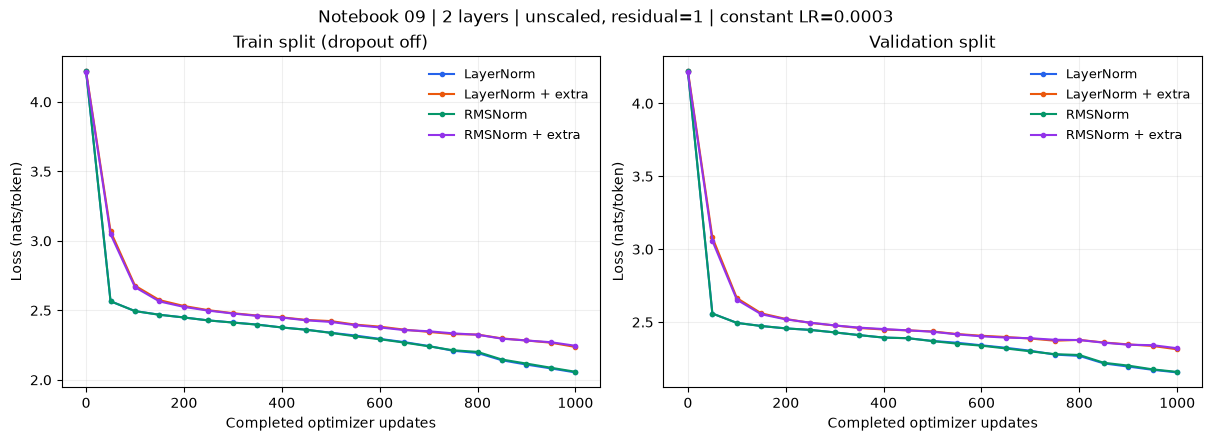

In [11]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(2, 'unscaled', experiment, RUN_DIR)
else:
    print('Training disabled: 2 layers / unscaled.')
### End normalization-ablation code ###


Reusing L02-U-A as L02-S-A; no second training run.
Reusing L02-U-B as L02-S-B; no second training run.
Reusing L02-U-C as L02-S-C; no second training run.
Reusing L02-U-D as L02-S-D; no second training run.


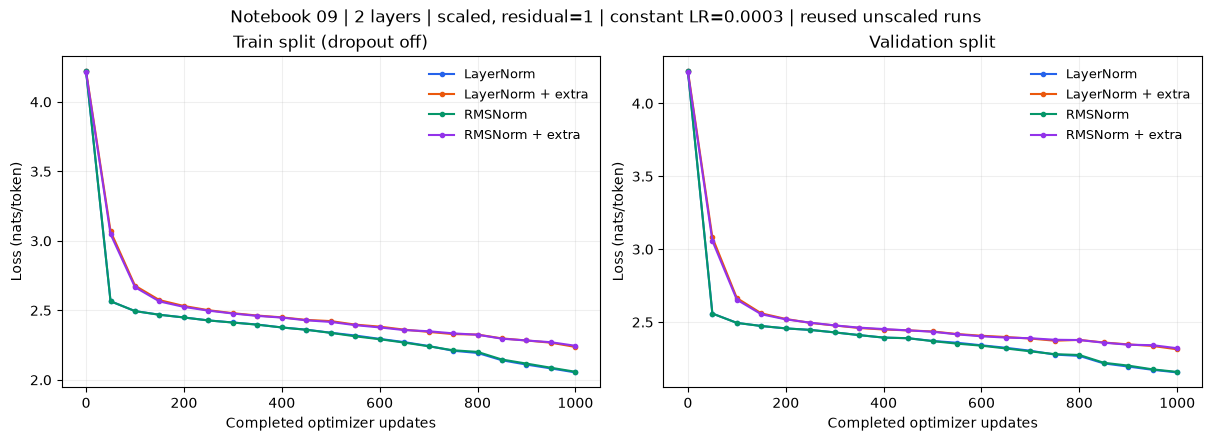

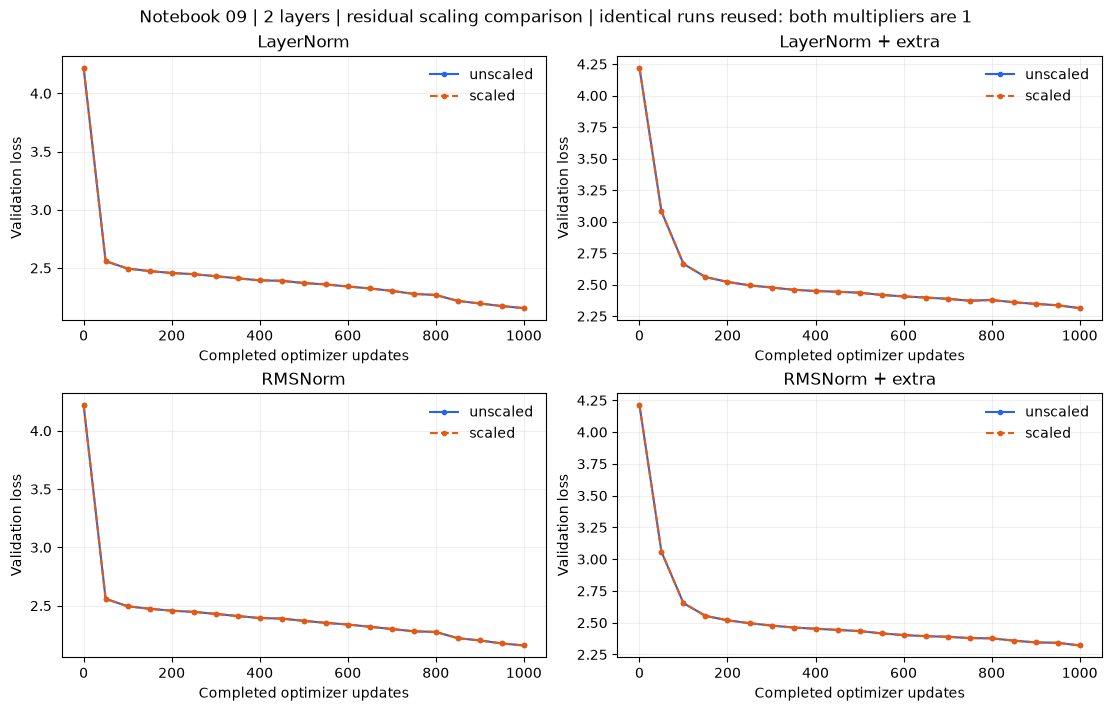

DEPTH REPORT READY: 2 layers; three PNG figures saved for this task.


In [12]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(2, 'scaled', experiment, RUN_DIR)
else:
    print('Training disabled: 2 layers / scaled.')
### End normalization-ablation code ###


## 4 layers — unscaled, then scaled, then comparison

Run four norms in each condition. Both conditions train independently from the same seeded initial matrices and sampled windows. The two cells display all three figures as soon as this depth is complete.


number of parameters: 3.16M
num decayed parameter tensors: 18, with 3,227,904 parameters
num non-decayed parameter tensors: 9, with 2,304 parameters
using fused AdamW: False


L04-U-A | LayerNorm          |    0 updates | train 4.2666 | val 4.2676


L04-U-A | LayerNorm          |   50 updates | train 2.5622 | val 2.5594


L04-U-A | LayerNorm          |  100 updates | train 2.4928 | val 2.4906


L04-U-A | LayerNorm          |  150 updates | train 2.4635 | val 2.4689


...

L04-U-D | RMSNorm + extra    |  800 updates | train 2.1544 | val 2.1960


L04-U-D | RMSNorm + extra    |  850 updates | train 2.1192 | val 2.1700


L04-U-D | RMSNorm + extra    |  900 updates | train 2.0727 | val 2.1249


L04-U-D | RMSNorm + extra    |  950 updates | train 2.0471 | val 2.1052


L04-U-D | RMSNorm + extra    | 1000 updates | train 2.0101 | val 2.0758


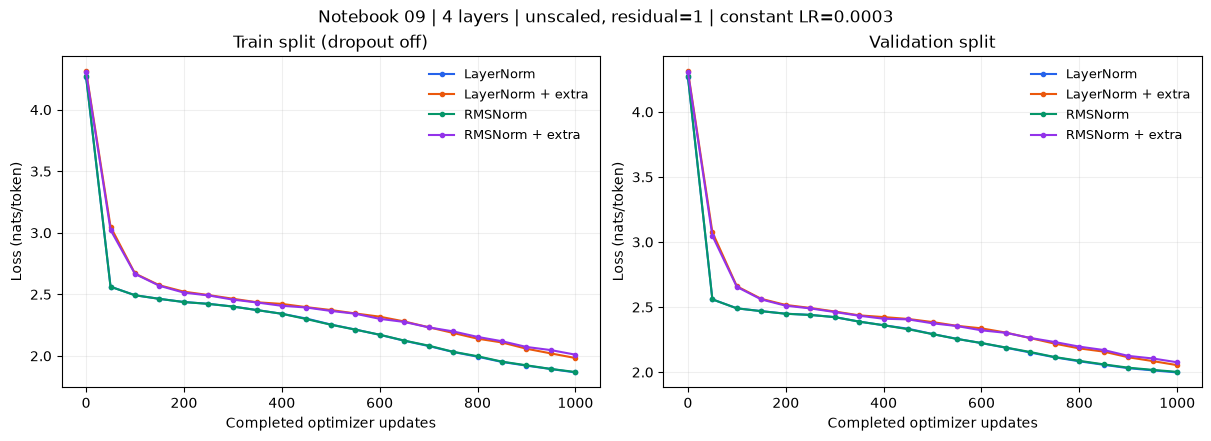

In [13]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(4, 'unscaled', experiment, RUN_DIR)
else:
    print('Training disabled: 4 layers / unscaled.')
### End normalization-ablation code ###


number of parameters: 3.16M
num decayed parameter tensors: 18, with 3,227,904 parameters
num non-decayed parameter tensors: 9, with 2,304 parameters
using fused AdamW: False


L04-S-A | LayerNorm          |    0 updates | train 4.2539 | val 4.2548


L04-S-A | LayerNorm          |   50 updates | train 2.5550 | val 2.5527


L04-S-A | LayerNorm          |  100 updates | train 2.4920 | val 2.4918


L04-S-A | LayerNorm          |  150 updates | train 2.4654 | val 2.4716


...

L04-S-D | RMSNorm + extra    |  800 updates | train 2.0817 | val 2.1510


L04-S-D | RMSNorm + extra    |  850 updates | train 2.0376 | val 2.1196


L04-S-D | RMSNorm + extra    |  900 updates | train 1.9985 | val 2.0825


L04-S-D | RMSNorm + extra    |  950 updates | train 1.9699 | val 2.0668


L04-S-D | RMSNorm + extra    | 1000 updates | train 1.9230 | val 2.0361


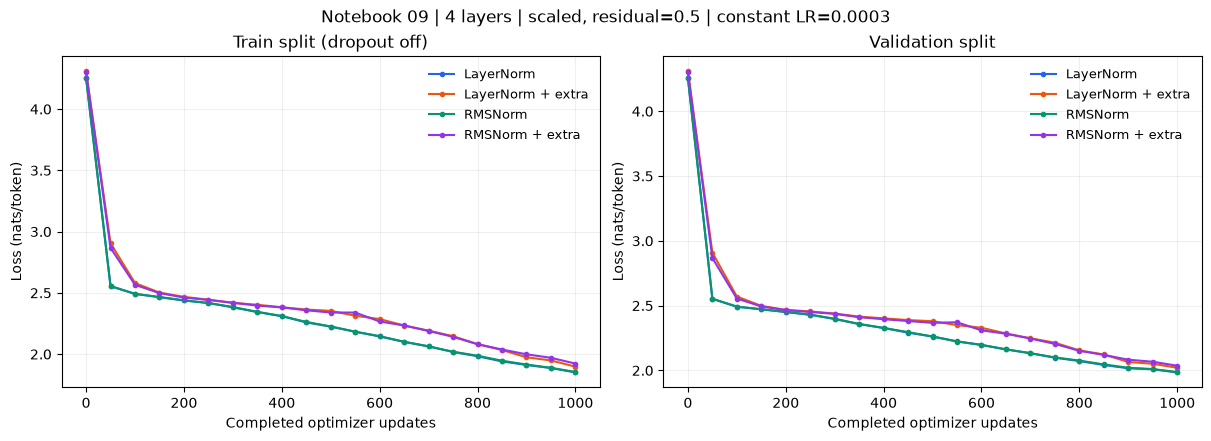

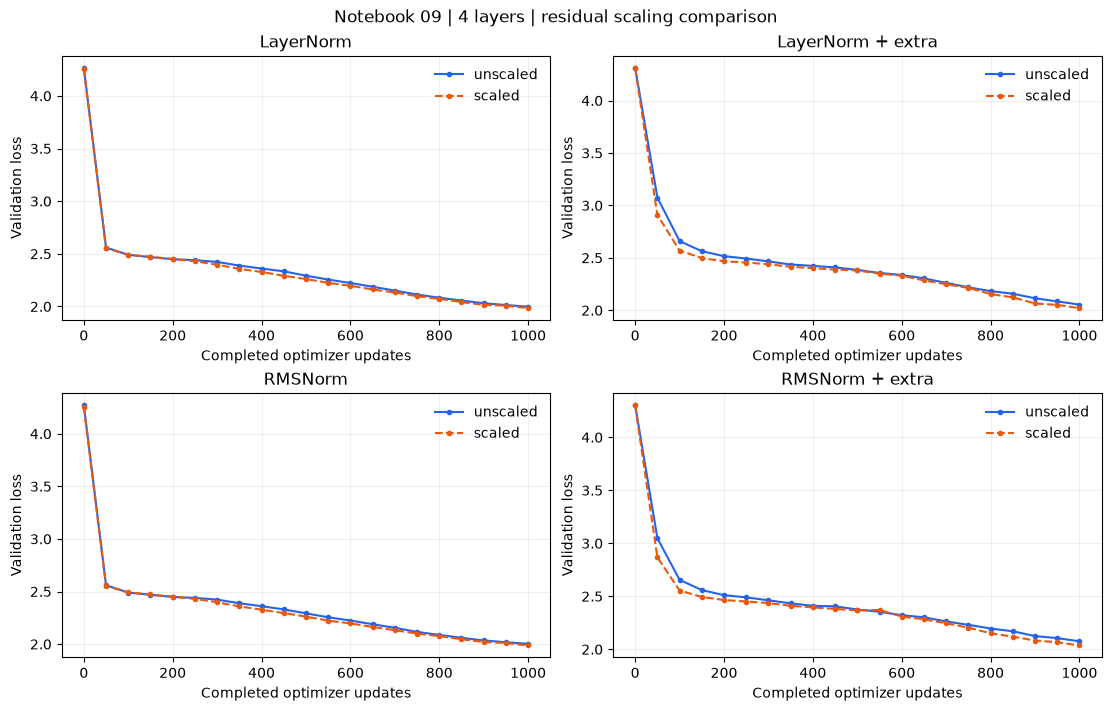

DEPTH REPORT READY: 4 layers; three PNG figures saved for this task.


In [14]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(4, 'scaled', experiment, RUN_DIR)
else:
    print('Training disabled: 4 layers / scaled.')
### End normalization-ablation code ###


## 8 layers — unscaled, then scaled, then comparison

Run four norms in each condition. Both conditions train independently from the same seeded initial matrices and sampled windows. The two cells display all three figures as soon as this depth is complete.


number of parameters: 6.31M
num decayed parameter tensors: 34, with 6,373,632 parameters
num non-decayed parameter tensors: 17, with 4,352 parameters
using fused AdamW: False


L08-U-A | LayerNorm          |    0 updates | train 4.1543 | val 4.1559


L08-U-A | LayerNorm          |   50 updates | train 2.5739 | val 2.5682


L08-U-A | LayerNorm          |  100 updates | train 2.4979 | val 2.4966


L08-U-A | LayerNorm          |  150 updates | train 2.4614 | val 2.4665


...

L08-U-D | RMSNorm + extra    |  800 updates | train 2.0144 | val 2.0747


L08-U-D | RMSNorm + extra    |  850 updates | train 1.9643 | val 2.0317


L08-U-D | RMSNorm + extra    |  900 updates | train 1.9227 | val 2.0004


L08-U-D | RMSNorm + extra    |  950 updates | train 1.8932 | val 1.9897


L08-U-D | RMSNorm + extra    | 1000 updates | train 1.8549 | val 1.9577


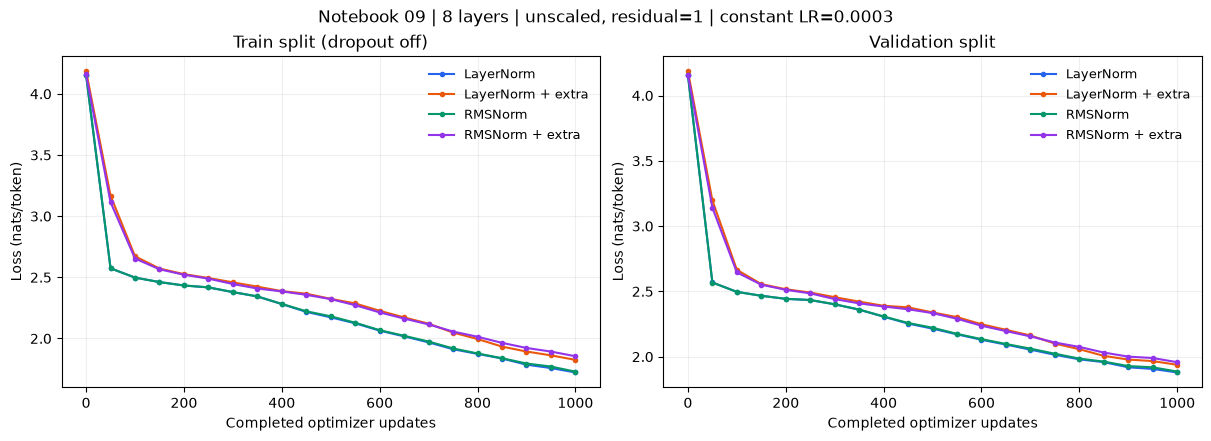

In [15]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(8, 'unscaled', experiment, RUN_DIR)
else:
    print('Training disabled: 8 layers / unscaled.')
### End normalization-ablation code ###


number of parameters: 6.31M
num decayed parameter tensors: 34, with 6,373,632 parameters
num non-decayed parameter tensors: 17, with 4,352 parameters
using fused AdamW: False


L08-S-A | LayerNorm          |    0 updates | train 4.1819 | val 4.1834


L08-S-A | LayerNorm          |   50 updates | train 2.5604 | val 2.5590


L08-S-A | LayerNorm          |  100 updates | train 2.4979 | val 2.5002


L08-S-A | LayerNorm          |  150 updates | train 2.4632 | val 2.4724


...

L08-S-D | RMSNorm + extra    |  800 updates | train 1.9227 | val 2.0107


L08-S-D | RMSNorm + extra    |  850 updates | train 1.8726 | val 1.9797


L08-S-D | RMSNorm + extra    |  900 updates | train 1.8275 | val 1.9411


L08-S-D | RMSNorm + extra    |  950 updates | train 1.8011 | val 1.9290


L08-S-D | RMSNorm + extra    | 1000 updates | train 1.7563 | val 1.9016


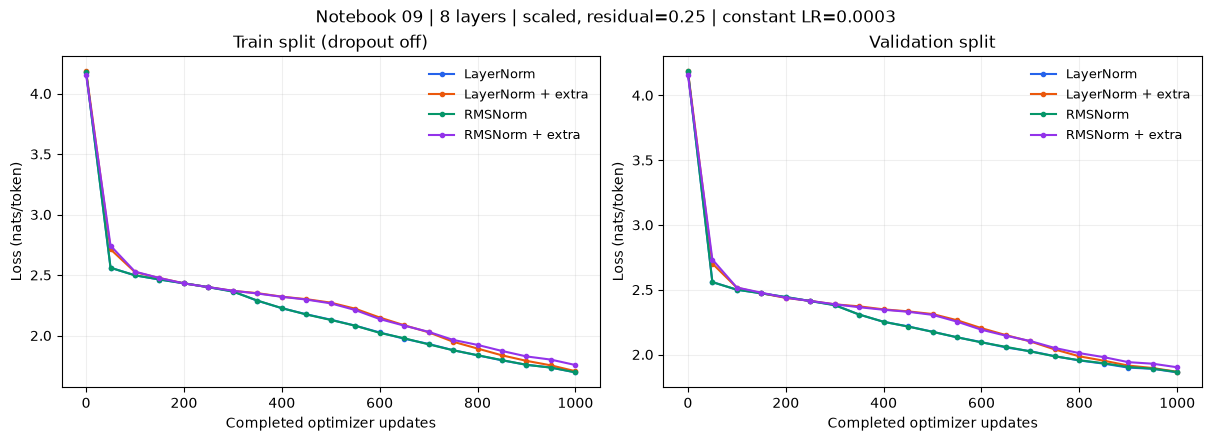

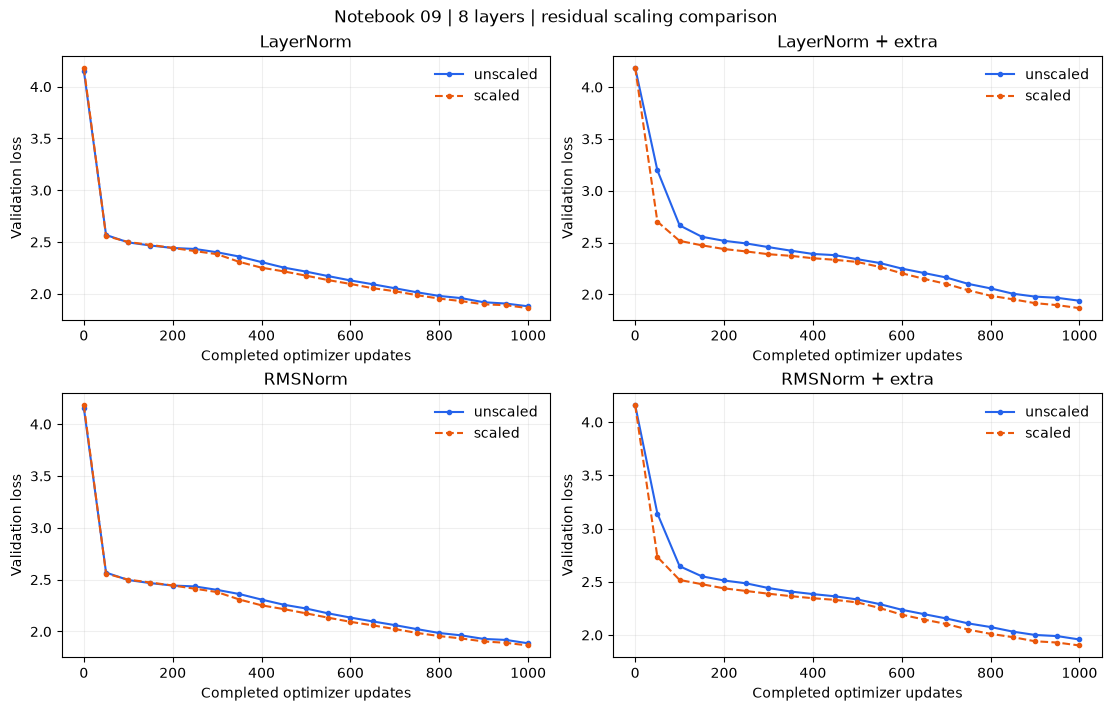

DEPTH REPORT READY: 8 layers; three PNG figures saved for this task.


In [16]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(8, 'scaled', experiment, RUN_DIR)
else:
    print('Training disabled: 8 layers / scaled.')
### End normalization-ablation code ###


## 16 layers — unscaled, then scaled, then comparison

Run four norms in each condition. Both conditions train independently from the same seeded initial matrices and sampled windows. The two cells display all three figures as soon as this depth is complete.


number of parameters: 12.61M
num decayed parameter tensors: 66, with 12,665,088 parameters
num non-decayed parameter tensors: 33, with 8,448 parameters
using fused AdamW: False


L16-U-A | LayerNorm          |    0 updates | train 4.2005 | val 4.1979


L16-U-A | LayerNorm          |   50 updates | train 2.5914 | val 2.5863


L16-U-A | LayerNorm          |  100 updates | train 2.5081 | val 2.5061


L16-U-A | LayerNorm          |  150 updates | train 2.4697 | val 2.4708


...

L16-U-D | RMSNorm + extra    |  800 updates | train 2.0182 | val 2.0733


L16-U-D | RMSNorm + extra    |  850 updates | train 1.9612 | val 2.0271


L16-U-D | RMSNorm + extra    |  900 updates | train 1.9299 | val 2.0007


L16-U-D | RMSNorm + extra    |  950 updates | train 1.8726 | val 1.9669


L16-U-D | RMSNorm + extra    | 1000 updates | train 1.8188 | val 1.9255


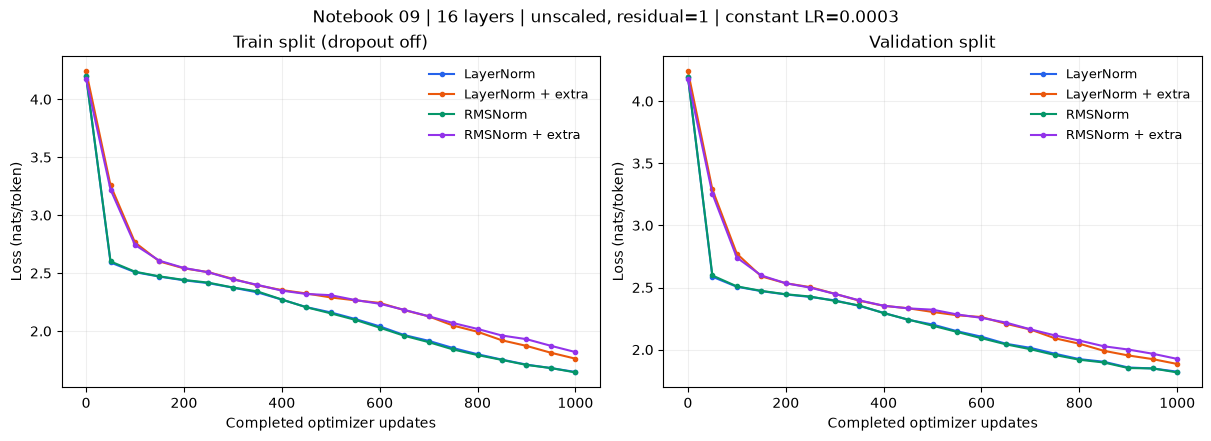

In [17]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(16, 'unscaled', experiment, RUN_DIR)
else:
    print('Training disabled: 16 layers / unscaled.')
### End normalization-ablation code ###


number of parameters: 12.61M
num decayed parameter tensors: 66, with 12,665,088 parameters
num non-decayed parameter tensors: 33, with 8,448 parameters
using fused AdamW: False


L16-S-A | LayerNorm          |    0 updates | train 4.2272 | val 4.2218


L16-S-A | LayerNorm          |   50 updates | train 2.5608 | val 2.5628


L16-S-A | LayerNorm          |  100 updates | train 2.4964 | val 2.5020


L16-S-A | LayerNorm          |  150 updates | train 2.4625 | val 2.4721


...

L16-S-D | RMSNorm + extra    |  800 updates | train 1.9099 | val 2.0073


L16-S-D | RMSNorm + extra    |  850 updates | train 1.8566 | val 1.9731


L16-S-D | RMSNorm + extra    |  900 updates | train 1.7989 | val 1.9164


L16-S-D | RMSNorm + extra    |  950 updates | train 1.7561 | val 1.8994


L16-S-D | RMSNorm + extra    | 1000 updates | train 1.7170 | val 1.8724


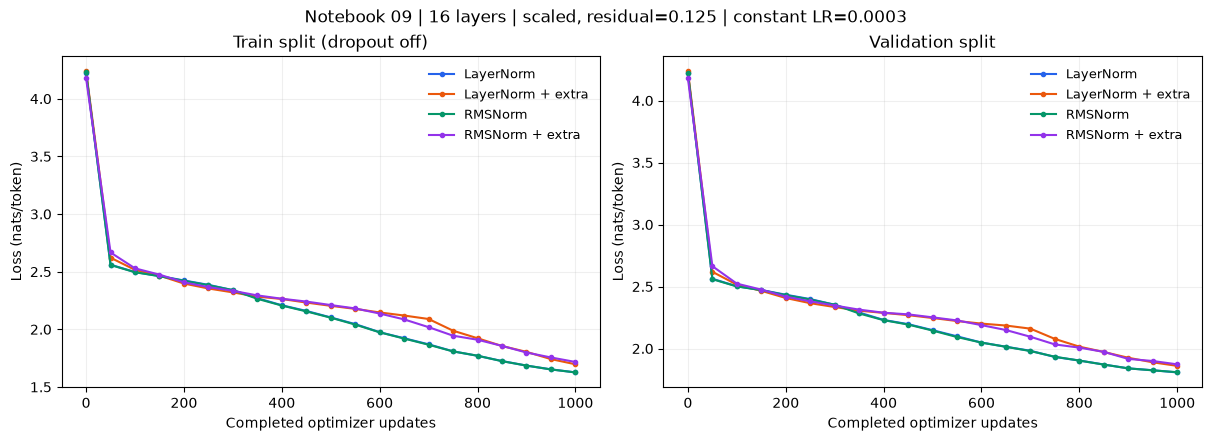

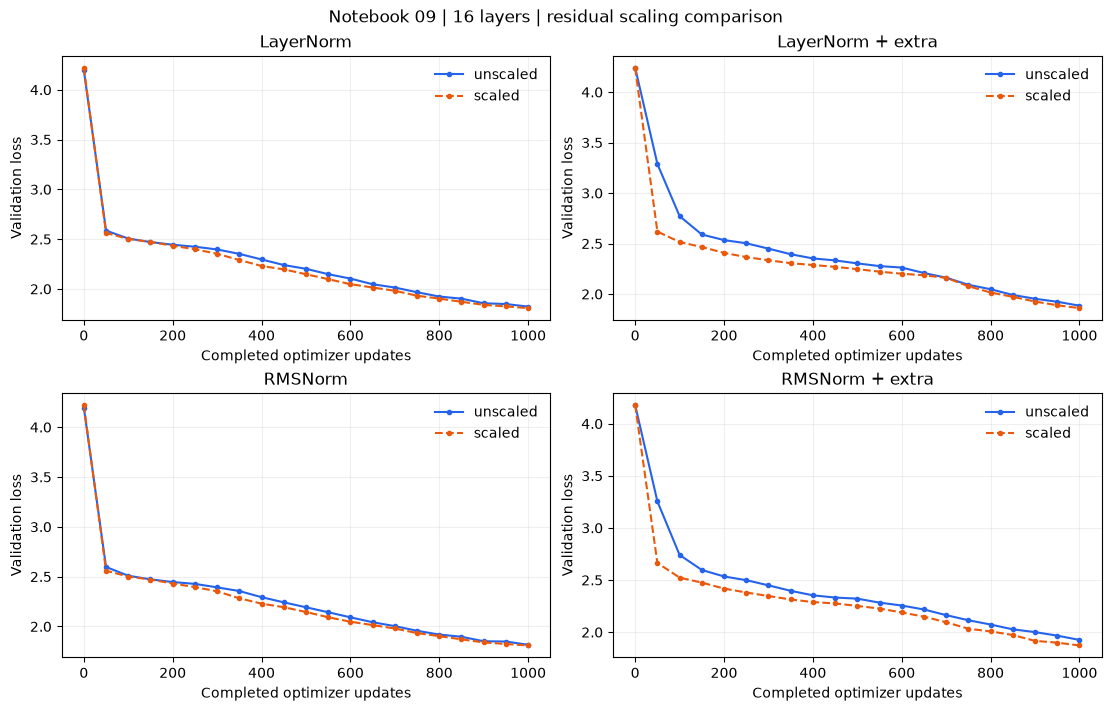

DEPTH REPORT READY: 16 layers; three PNG figures saved for this task.


In [18]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(16, 'scaled', experiment, RUN_DIR)
else:
    print('Training disabled: 16 layers / scaled.')
### End normalization-ablation code ###


## 32 layers — unscaled, then scaled, then comparison

Run four norms in each condition. Both conditions train independently from the same seeded initial matrices and sampled windows. The two cells display all three figures as soon as this depth is complete.


number of parameters: 25.20M
num decayed parameter tensors: 130, with 25,248,000 parameters
num non-decayed parameter tensors: 65, with 16,640 parameters
using fused AdamW: False


L32-U-A | LayerNorm          |    0 updates | train 4.2391 | val 4.2380


L32-U-A | LayerNorm          |   50 updates | train 2.7196 | val 2.7166


L32-U-A | LayerNorm          |  100 updates | train 2.5476 | val 2.5395


L32-U-A | LayerNorm          |  150 updates | train 2.4982 | val 2.4942


...

L32-U-D | RMSNorm + extra    |  800 updates | train 2.1322 | val 2.1589


L32-U-D | RMSNorm + extra    |  850 updates | train 2.0690 | val 2.1023


L32-U-D | RMSNorm + extra    |  900 updates | train 2.0195 | val 2.0646


L32-U-D | RMSNorm + extra    |  950 updates | train 1.9661 | val 2.0238


L32-U-D | RMSNorm + extra    | 1000 updates | train 1.9174 | val 1.9830


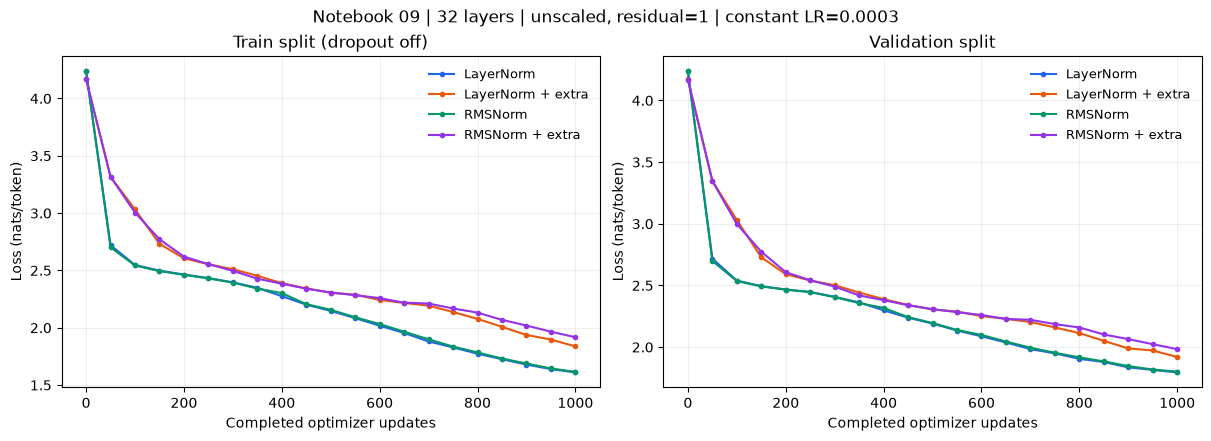

In [19]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(32, 'unscaled', experiment, RUN_DIR)
else:
    print('Training disabled: 32 layers / unscaled.')
### End normalization-ablation code ###


number of parameters: 25.20M
num decayed parameter tensors: 130, with 25,248,000 parameters
num non-decayed parameter tensors: 65, with 16,640 parameters
using fused AdamW: False


L32-S-A | LayerNorm          |    0 updates | train 4.2545 | val 4.2473


L32-S-A | LayerNorm          |   50 updates | train 2.5576 | val 2.5603


L32-S-A | LayerNorm          |  100 updates | train 2.4970 | val 2.4993


L32-S-A | LayerNorm          |  150 updates | train 2.4550 | val 2.4668


...

L32-S-D | RMSNorm + extra    |  800 updates | train 1.9210 | val 2.0282


L32-S-D | RMSNorm + extra    |  850 updates | train 1.8676 | val 1.9917


L32-S-D | RMSNorm + extra    |  900 updates | train 1.8202 | val 1.9472


L32-S-D | RMSNorm + extra    |  950 updates | train 1.7787 | val 1.9234


L32-S-D | RMSNorm + extra    | 1000 updates | train 1.7440 | val 1.8932


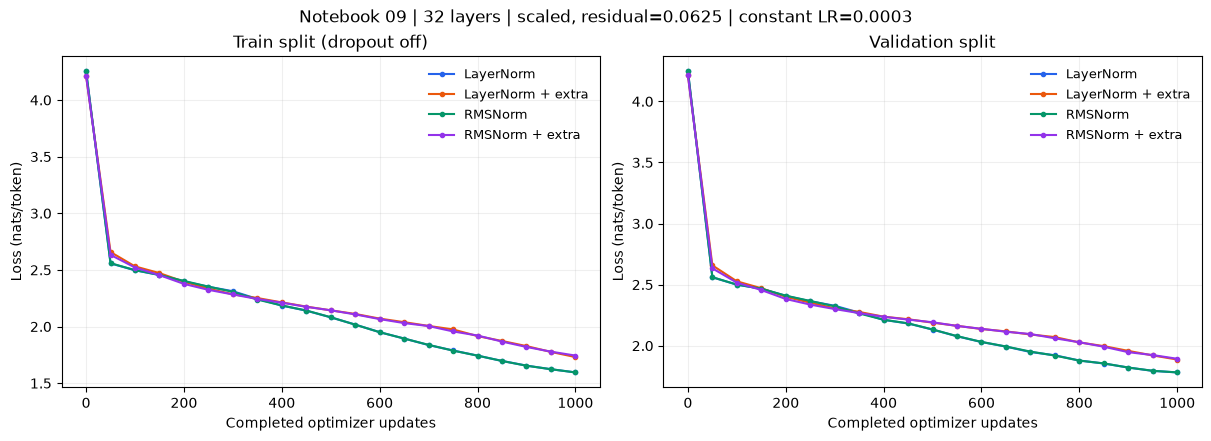

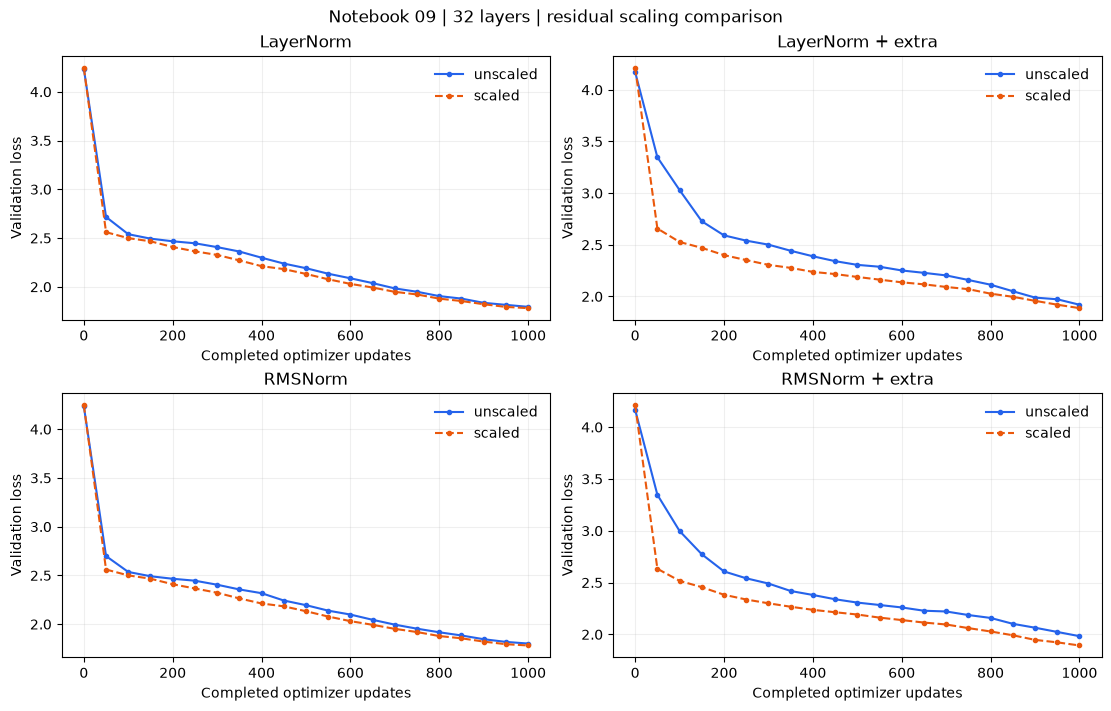

DEPTH REPORT READY: 32 layers; three PNG figures saved for this task.


In [20]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(32, 'scaled', experiment, RUN_DIR)
else:
    print('Training disabled: 32 layers / scaled.')
### End normalization-ablation code ###


## 64 layers — unscaled, then scaled, then comparison

Run four norms in each condition. Both conditions train independently from the same seeded initial matrices and sampled windows. The two cells display all three figures as soon as this depth is complete.


number of parameters: 50.38M
num decayed parameter tensors: 258, with 50,413,824 parameters
num non-decayed parameter tensors: 129, with 33,024 parameters
using fused AdamW: False


L64-U-A | LayerNorm          |    0 updates | train 4.2815 | val 4.2769


L64-U-A | LayerNorm          |   50 updates | train 2.9615 | val 2.9740


L64-U-A | LayerNorm          |  100 updates | train 2.6232 | val 2.6172


L64-U-A | LayerNorm          |  150 updates | train 2.5356 | val 2.5305


...

L64-U-D | RMSNorm + extra    |  800 updates | train 2.1288 | val 2.1569


L64-U-D | RMSNorm + extra    |  850 updates | train 2.0818 | val 2.1186


L64-U-D | RMSNorm + extra    |  900 updates | train 2.0396 | val 2.0796


L64-U-D | RMSNorm + extra    |  950 updates | train 1.9990 | val 2.0528


L64-U-D | RMSNorm + extra    | 1000 updates | train 1.9612 | val 2.0236


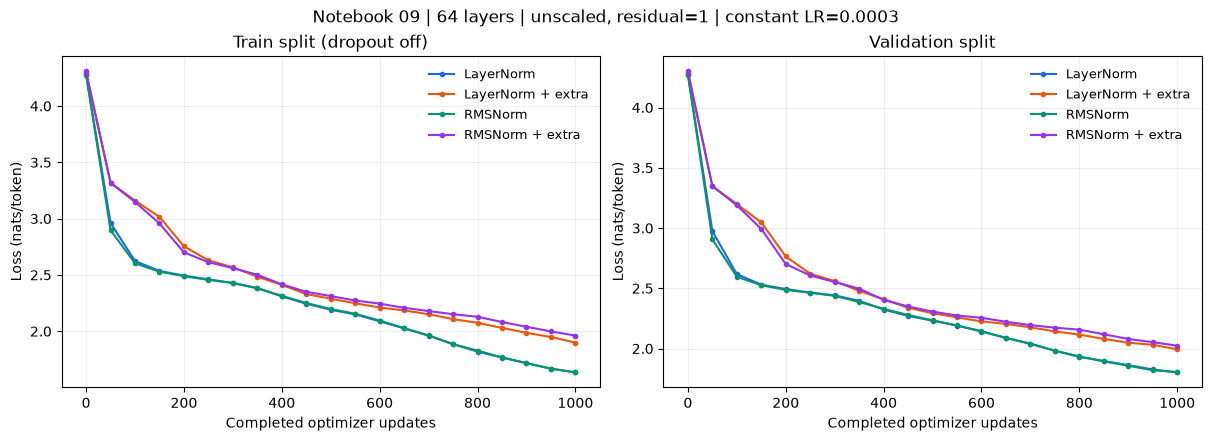

In [21]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(64, 'unscaled', experiment, RUN_DIR)
else:
    print('Training disabled: 64 layers / unscaled.')
### End normalization-ablation code ###


number of parameters: 50.38M
num decayed parameter tensors: 258, with 50,413,824 parameters
num non-decayed parameter tensors: 129, with 33,024 parameters
using fused AdamW: False


L64-S-A | LayerNorm          |    0 updates | train 4.3565 | val 4.3441


L64-S-A | LayerNorm          |   50 updates | train 2.5699 | val 2.5710


L64-S-A | LayerNorm          |  100 updates | train 2.5002 | val 2.5043


L64-S-A | LayerNorm          |  150 updates | train 2.4629 | val 2.4781


...

L64-S-D | RMSNorm + extra    |  800 updates | train 1.8563 | val 1.9710


L64-S-D | RMSNorm + extra    |  850 updates | train 1.8119 | val 1.9440


L64-S-D | RMSNorm + extra    |  900 updates | train 1.7695 | val 1.9128


L64-S-D | RMSNorm + extra    |  950 updates | train 1.7485 | val 1.9013


L64-S-D | RMSNorm + extra    | 1000 updates | train 1.7087 | val 1.8767


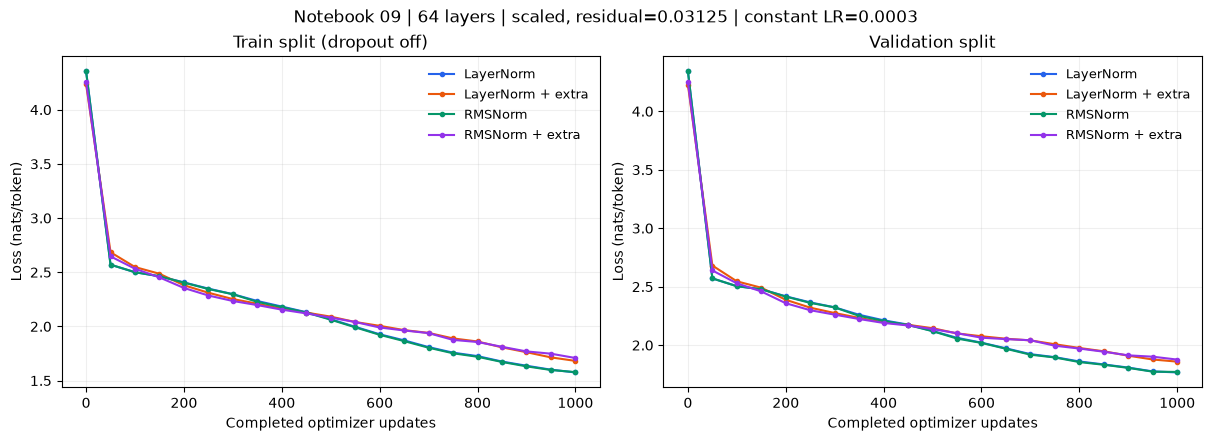

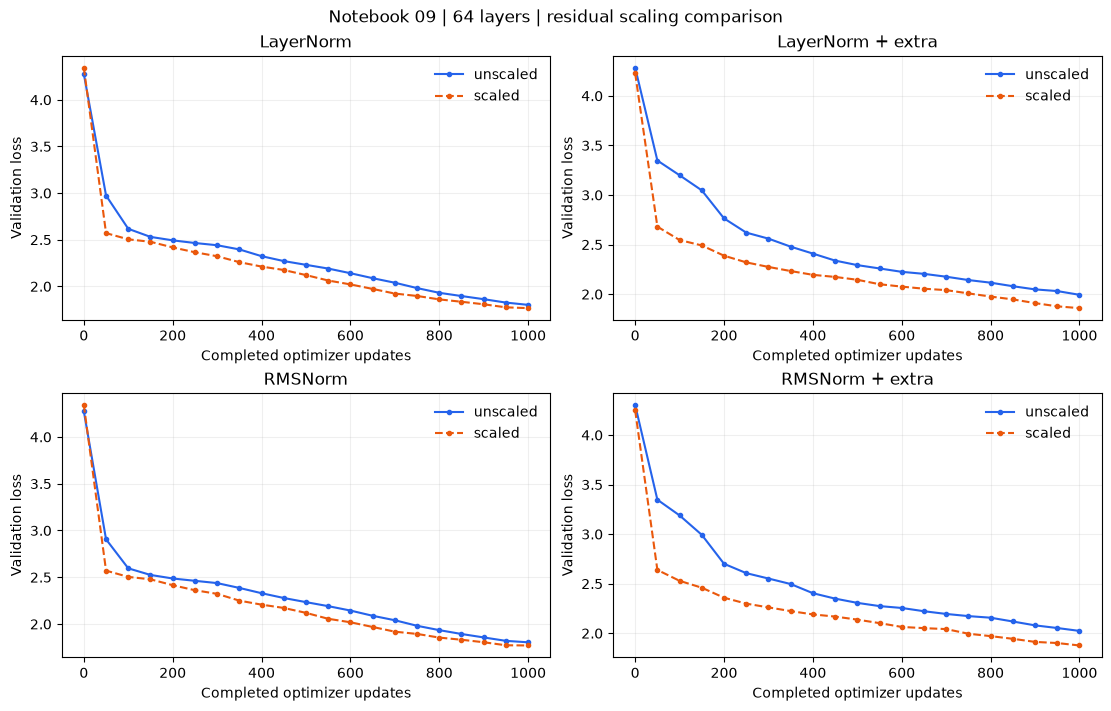

DEPTH REPORT READY: 64 layers; three PNG figures saved for this task.


In [22]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# This cell trains only its specified condition when explicitly enabled.
if RUN_TRAINING:
    run_condition(64, 'scaled', experiment, RUN_DIR)
else:
    print('Training disabled: 64 layers / scaled.')
### End normalization-ablation code ###


## Finish and verify the requested total


In [23]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
if RUN_TRAINING:
    assert len(experiment['results']) == 44
    assert {r['id'] for r in experiment['results']} == set(VARIANT_BY_ID)
    assert all(r['completed_updates'] == cfg.max_updates and len(r['training']) == cfg.max_updates
               for r in experiment['results'])
    assert all(experiment['depth_reports'][str(depth)]['target_updates'] == cfg.max_updates for depth in DEPTHS)
    experiment['status'] = 'complete'
    experiment['sessions'][-1]['finished_utc'] = datetime.now(timezone.utc).isoformat()
    save_metrics(experiment, RUN_DIR)
    write_progress(experiment, RUN_DIR)
    print('Complete: 44 actual runs, 48 comparison entries, six reports with three figures each.')
else:
    print('No experiments have been launched by this notebook.')
### End normalization-ablation code ###


Complete: 44 actual runs, 48 comparison entries, six reports with three figures each.


## Re-display saved figures after an interruption — no training

Set `SAVED_RESULTS_FILE` to this notebook's saved `metrics.json` and run only the imports and this cell. It displays existing report images without constructing a model or executing training. Incomplete depth reports are omitted. Depth-2 scaled results are reused, not a second sample.


In [24]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
from IPython.display import Image
SAVED_RESULTS_FILE = None  # Path('/absolute/path/to/Notebook-09-run/metrics.json')
if SAVED_RESULTS_FILE is None:
    print('No saved Notebook 09 result selected; no training or plotting is started.')
else:
    saved = json.loads(Path(SAVED_RESULTS_FILE).read_text())
    for depth_text, report in sorted(saved.get('depth_reports', {}).items(), key=lambda item: int(item[0])):
        display(Markdown(f"### {depth_text} layers — {report['target_updates']} updates"))
        if report.get('reused_depth2'):
            display(Markdown('Depth 2 reuses the same four runs for both residual labels.'))
        for path in report['png_paths']:
            display(Image(filename=path))
### End normalization-ablation code ###


No saved Notebook 09 result selected; no training or plotting is started.


## Combined printable overview — all depths, four methods together

This **presentation-only** section reads the saved Notebook 09 results. Run **only the final code cell** to regenerate the overview; earlier training cells are not needed. This cell is self-contained and can run from a fresh kernel.

- **Layout:** six rows (2, 4, 8, 16, 32, 64 layers) × two columns (unscaled / scaled). Every panel keeps all four normalization methods together.
- **Visual encoding:** blue = LayerNorm, orange = RMSNorm; solid = baseline, dashed = extra normalization. Four distinct hollow markers are staggered to distinguish overlapping curves.
- **Extra normalization:** applied before W_O after head concatenation, and before W_2 after GELU, in addition to the standard pre-norm locations.
- **Loss:** raw validation evaluations over 0–1000 optimizer updates. Each panel includes a magnified view of updates 800–1000. Both columns share the same main and inset y-limits within each depth; limits may differ across depths. No smoothing or artificial offsets are applied.
- **Counting:** 48 displayed conditions represent 44 actual training runs. The two-layer conditions reuse the same four histories because both residual factors equal 1. This is a single-seed comparison.
- **Output:** the full PNG is embedded below and saved at 300 dpi; a vector PDF is exported as one A3 portrait page. Use the PNG for copying/sharing and the PDF for printing. The image remains visible in the saved notebook without rerunning training.


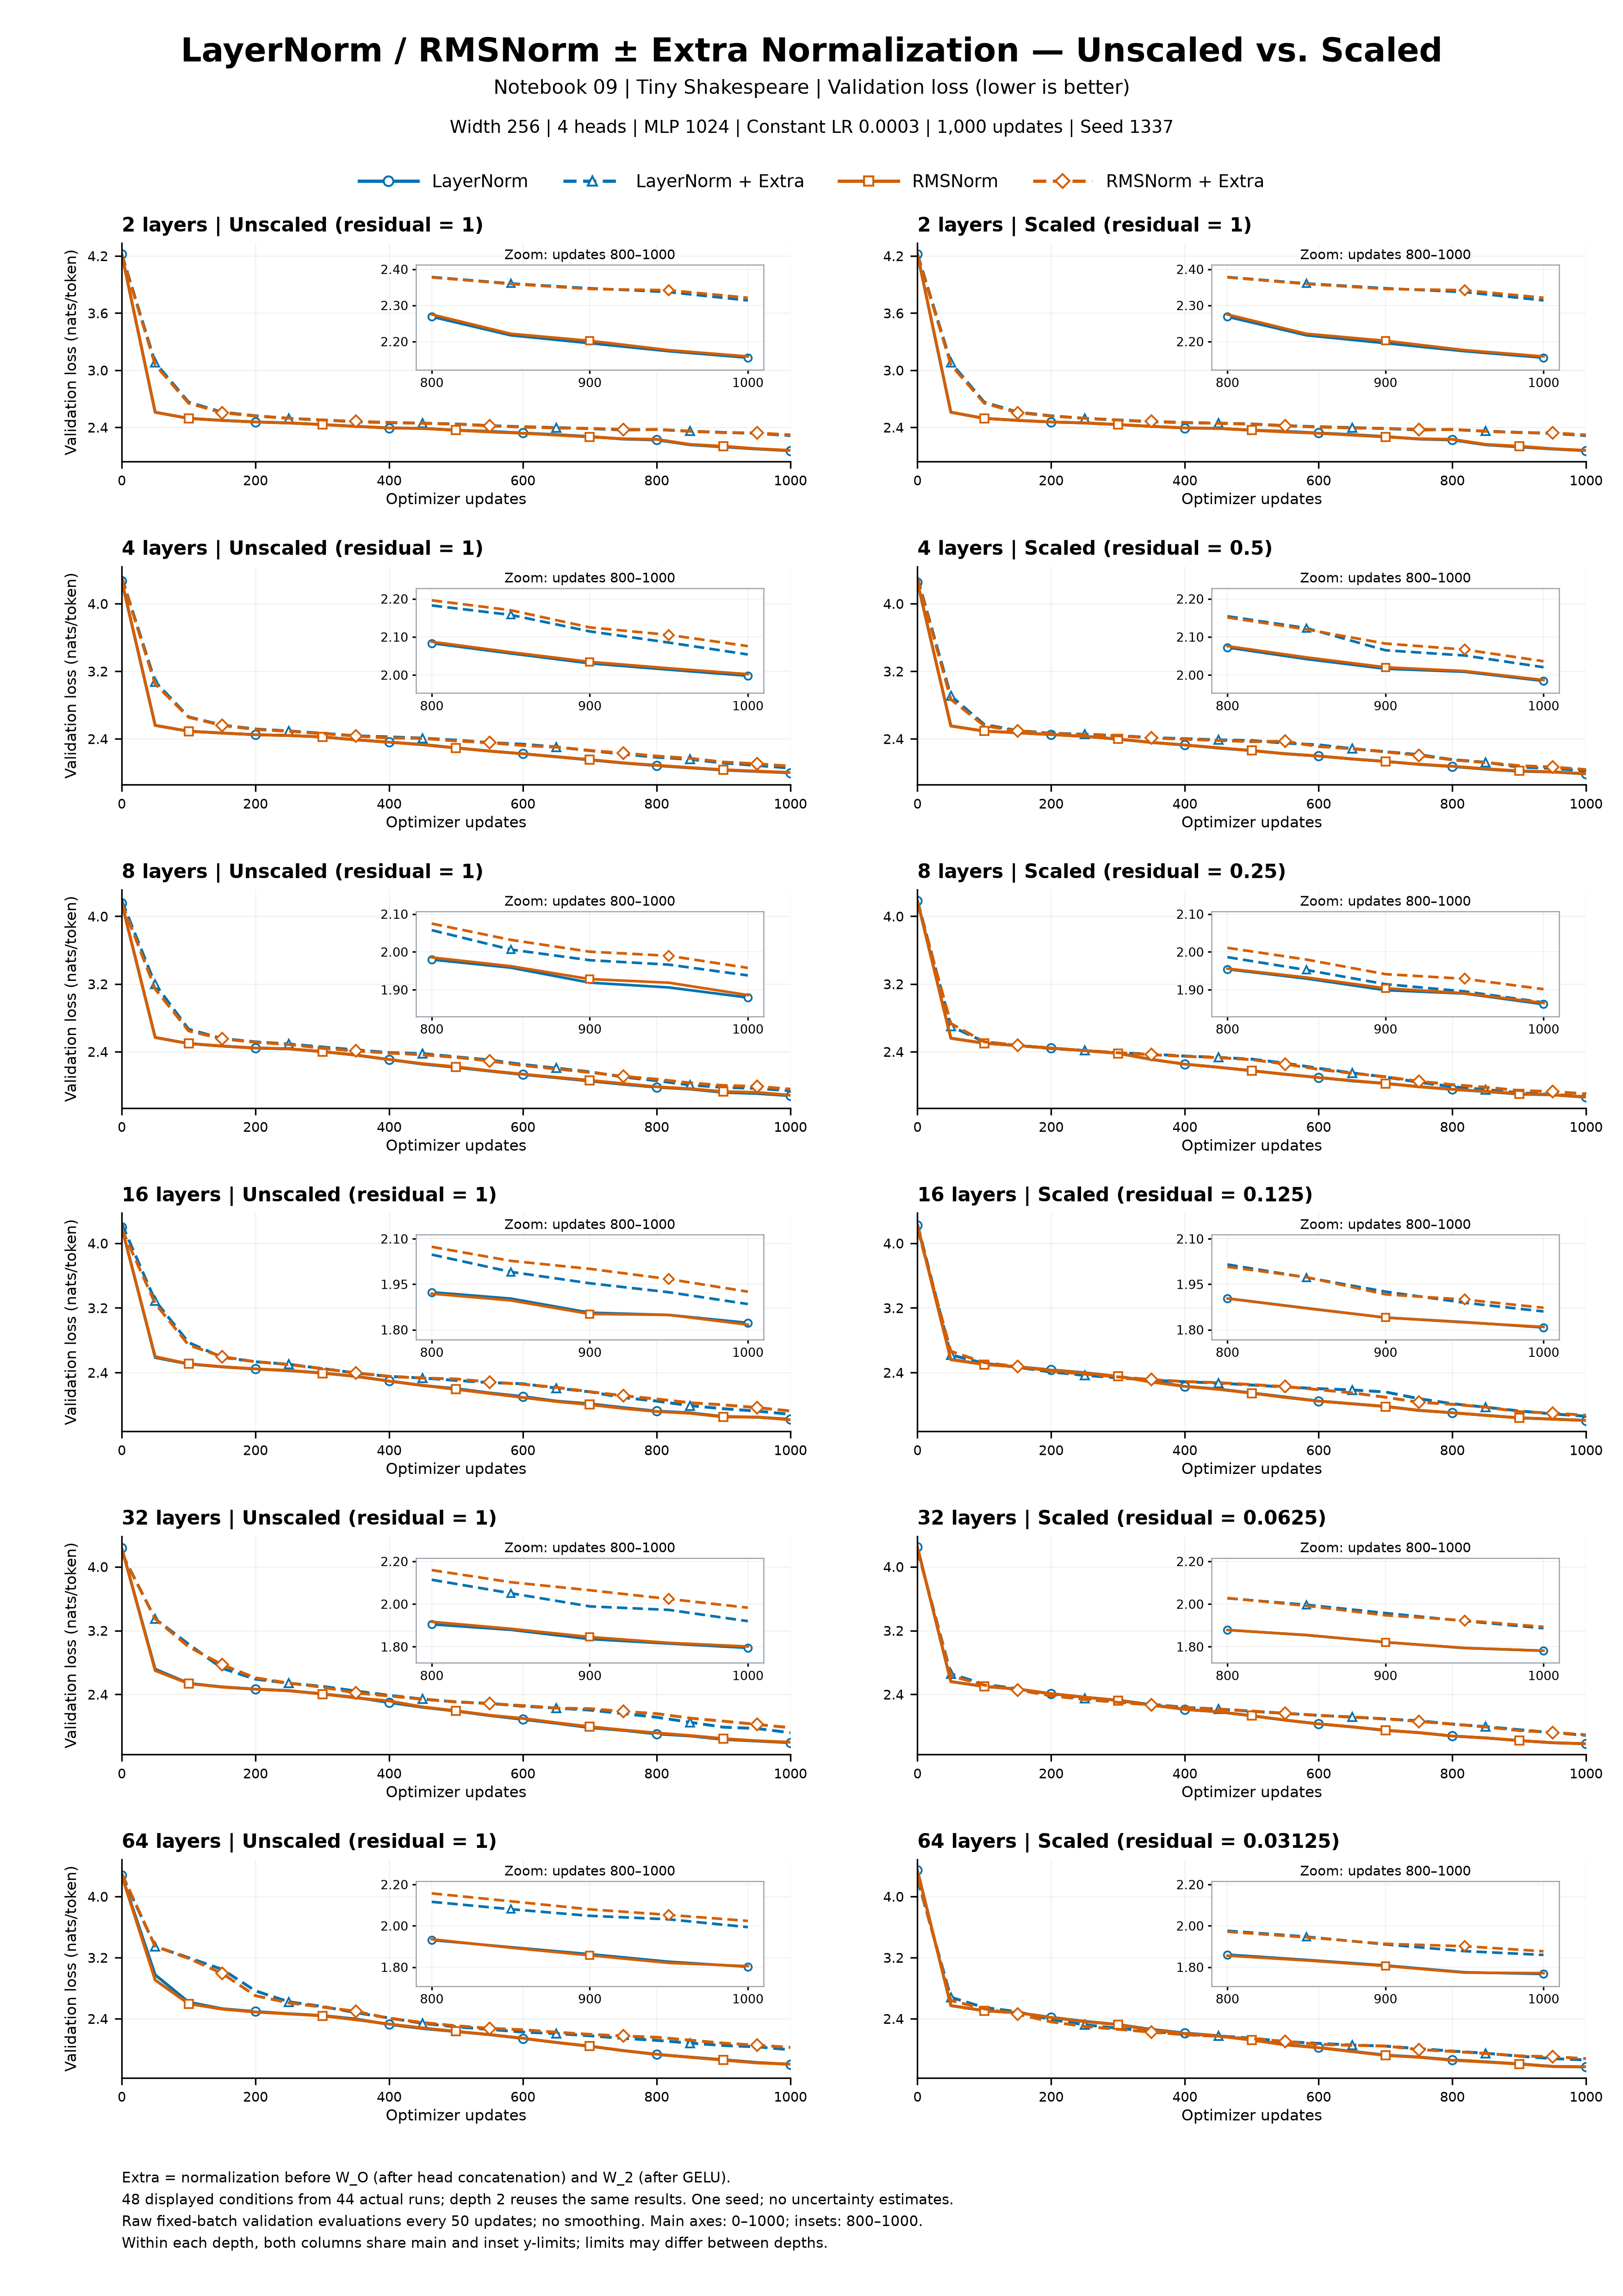

/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/residual-scaling-fixed-lr/20260915T030453Z-9e4ce2ff/figures/1000-updates/combined-overview/notebook09-all-depths-validation.png

/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/residual-scaling-fixed-lr/20260915T030453Z-9e4ce2ff/figures/1000-updates/combined-overview/notebook09-all-depths-validation-A3.pdf

Saved overview: 48 displayed conditions / 44 actual runs; all at 1000 updates.
/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/residual-scaling-fixed-lr/20260915T030453Z-9e4ce2ff/figures/1000-updates/combined-overview/notebook09-all-depths-validation.png
/Users/linyuntao/Library/Mobile Documents/iCloud~md~obsidian/Documents/obsidian/research_workspace/projects/Adam - Normalization/Code/MiniP/results/residual-scaling-fixed-lr/20260915T030453Z-9e4ce2ff/figures/1000-updates/combined-overview/notebook09-all-depths-validation-A3.pdf


In [1]:
### Begin normalization-ablation code ###
# Branch: codex/normalization-ablation.
# Presentation only: run this cell independently to read saved results and export
# one A3 portrait overview. No model, optimizer, or training code is called.
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from IPython.display import Image, FileLink, display

# 1. Saved experiment and export settings.
# Resolve MiniP from either its root or its notebooks directory. Pin the original
# run explicitly so a later experiment cannot silently change this report.
OVERVIEW_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / 'notebooks' / '09-residual-scaling-fixed-lr-ablation.ipynb').is_file()
)
OVERVIEW_RUN_DIR = OVERVIEW_ROOT / 'results/residual-scaling-fixed-lr/20260915T030453Z-9e4ce2ff'
OVERVIEW_TARGET = 1000
OVERVIEW_ZOOM_START = 800
OVERVIEW_DEPTHS = (2, 4, 8, 16, 32, 64)
OVERVIEW_DPI = 300
overview_output_dir = OVERVIEW_RUN_DIR / 'figures' / '1000-updates' / 'combined-overview'
overview_output_dir.mkdir(parents=True, exist_ok=True)

# 2. Resolve 48 display conditions to 44 real training histories.
# At depth 2, scaled and unscaled use the same four source runs (2/L = 1).
overview_metrics = json.loads((OVERVIEW_RUN_DIR / 'metrics.json').read_text())
overview_results = {r['id']: r for r in overview_metrics['results']}
overview_entries = {
    (v['depth'], v['mode'], v['norm_id']): v
    for v in overview_metrics['display_variants']
}
assert len(overview_results) == 44 and len(overview_entries) == 48
overview_histories = {}
for depth in OVERVIEW_DEPTHS:
    for mode in ('unscaled', 'scaled'):
        for norm in 'ABCD':
            entry = overview_entries[depth, mode, norm]
            result = overview_results[entry['source_id']]
            assert result['completed_updates'] >= OVERVIEW_TARGET, entry['source_id']
            rows = [e for e in result['evaluations']
                    if e['completed_updates'] <= OVERVIEW_TARGET]
            assert [e['completed_updates'] for e in rows] == list(range(0, 1001, 50))
            assert all(math.isfinite(e['val_loss']) for e in rows)
            overview_histories[depth, mode, norm] = rows
for norm in 'ABCD':
    assert (overview_entries[2, 'unscaled', norm]['source_id'] ==
            overview_entries[2, 'scaled', norm]['source_id'])

# 3. Encode two experimental factors independently.
# Color = LayerNorm / RMSNorm; solid / dashed = baseline / extra normalization.
# Hollow markers are staggered across updates to expose overlapping curves.
# Exact saved values are used: no smoothing, offsets, or resampling.
overview_styles = {
    'A': dict(label='LayerNorm', color='#0072B2', linestyle='-', marker='o'),
    'B': dict(label='LayerNorm + Extra', color='#0072B2', linestyle=(0, (4, 2)), marker='^'),
    'C': dict(label='RMSNorm', color='#D55E00', linestyle='-', marker='s'),
    'D': dict(label='RMSNorm + Extra', color='#D55E00', linestyle=(0, (4, 2)), marker='D'),
}

def overview_draw_curves(ax, depth, mode, zoom=False):
    for offset, norm in enumerate('ABCD'):
        rows = overview_histories[depth, mode, norm]
        if zoom:
            rows = [e for e in rows if e['completed_updates'] >= OVERVIEW_ZOOM_START]
        ax.plot(
            [e['completed_updates'] for e in rows],
            [e['val_loss'] for e in rows],
            **overview_styles[norm],
            linewidth=1.35 if zoom else 1.5,
            markersize=3.8 if zoom else 4.4,
            markerfacecolor='white', markeredgewidth=0.9,
            markevery=(offset, 4),
        )

def overview_limits(values, fraction, minimum):
    lower, upper = min(values), max(values)
    padding = max((upper - lower) * fraction, minimum)
    return lower - padding, upper + padding

# 4. Build a single printable page: depths down the rows, scaling across columns.
# Each row shares full-range AND zoom-range limits across both scaling modes.
# Other depths may have different limits; read tick labels when comparing rows.
with plt.rc_context({'font.family': 'DejaVu Sans', 'font.size': 8,
                     'axes.titlesize': 10, 'axes.labelsize': 8,
                     'xtick.labelsize': 7, 'ytick.labelsize': 7,
                     'pdf.fonttype': 42, 'ps.fonttype': 42}):
    overview_fig, overview_axes = plt.subplots(6, 2, figsize=(297 / 25.4, 420 / 25.4))
    overview_fig.subplots_adjust(left=0.075, right=0.977, bottom=0.095,
                                top=0.894, hspace=0.48, wspace=0.19)
    overview_fig.suptitle('LayerNorm / RMSNorm ± Extra Normalization — Unscaled vs. Scaled',
                          y=0.984, fontsize=17, fontweight='bold')
    overview_fig.text(0.5, 0.959,
        'Notebook 09 | Tiny Shakespeare | Validation loss (lower is better)',
        ha='center', fontsize=10)
    overview_fig.text(0.5, 0.942,
        'Width 256 | 4 heads | MLP 1024 | Constant LR 0.0003 | 1,000 updates | Seed 1337',
        ha='center', fontsize=9)
    legend_handles = [Line2D([], [], **overview_styles[n], linewidth=1.7,
                            markersize=5, markerfacecolor='white') for n in 'ABCD']
    overview_fig.legend(handles=legend_handles, loc='upper center',
                        bbox_to_anchor=(0.5, 0.931), ncol=4, frameon=False,
                        fontsize=9, handlelength=3.4, columnspacing=2)

    for row_index, depth in enumerate(OVERVIEW_DEPTHS):
        all_rows = [e for mode in ('unscaled', 'scaled') for norm in 'ABCD'
                    for e in overview_histories[depth, mode, norm]]
        full_limits = overview_limits([e['val_loss'] for e in all_rows], 0.055, 0.04)
        zoom_limits = overview_limits(
            [e['val_loss'] for e in all_rows if e['completed_updates'] >= OVERVIEW_ZOOM_START],
            0.15, 0.012)
        for column, mode in enumerate(('unscaled', 'scaled')):
            ax = overview_axes[row_index, column]
            overview_draw_curves(ax, depth, mode)
            factor = 1.0 if mode == 'unscaled' else 2.0 / depth
            title_mode = 'Unscaled' if mode == 'unscaled' else 'Scaled'
            ax.set_title(f'{depth} layers | {title_mode} (residual = {factor:g})',
                         loc='left', pad=6, fontweight='bold')
            ax.set_xlim(0, OVERVIEW_TARGET)
            ax.set_ylim(*full_limits)
            ax.set_xticks([0, 200, 400, 600, 800, 1000])
            ax.set_xlabel('Optimizer updates', labelpad=2)
            if column == 0:
                ax.set_ylabel('Validation loss (nats/token)')
            ax.yaxis.set_major_locator(MaxNLocator(4))
            ax.grid(alpha=0.17, linewidth=0.6)
            ax.spines[['top', 'right']].set_visible(False)

            # Place a clearly labeled late-training magnification in empty space
            # above the converged curves. Tick labels expose the narrower scale.
            zoom_ax = ax.inset_axes([0.44, 0.42, 0.52, 0.48])
            overview_draw_curves(zoom_ax, depth, mode, zoom=True)
            zoom_ax.set_xlim(790, 1010)
            zoom_ax.set_ylim(*zoom_limits)
            zoom_ax.set_xticks([800, 900, 1000])
            zoom_ax.yaxis.set_major_locator(MaxNLocator(3))
            zoom_ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
            zoom_ax.tick_params(labelsize=6.5, length=2, pad=2)
            zoom_ax.set_title('Zoom: updates 800–1000', fontsize=7, pad=3)
            zoom_ax.grid(alpha=0.16, linewidth=0.5)
            for spine in zoom_ax.spines.values():
                spine.set_color('#9AA3AC')
                spine.set_linewidth(0.6)

    # Scientific interpretation and reuse are explicit in the printed artifact.
    overview_fig.text(0.075, 0.037,
        'Extra = normalization before W_O (after head concatenation) and W_2 (after GELU).\n'
        '48 displayed conditions from 44 actual runs; depth 2 reuses the same results. One seed; no uncertainty estimates.\n'
        'Raw fixed-batch validation evaluations every 50 updates; no smoothing. Main axes: 0–1000; insets: 800–1000.\n'
        'Within each depth, both columns share main and inset y-limits; limits may differ between depths.',
        ha='left', va='center', fontsize=7.5, linespacing=1.5)

    # 5. Save a 300 dpi PNG for copying and a vector, single-page A3 PDF for print.
    # Avoid tight cropping, which would change the PDF's exact A3 page dimensions.
    overview_png = overview_output_dir / 'notebook09-all-depths-validation.png'
    overview_pdf = overview_output_dir / 'notebook09-all-depths-validation-A3.pdf'
    for output_path in (overview_png, overview_pdf):
        temporary = output_path.with_name(output_path.stem + '.tmp' + output_path.suffix)
        overview_fig.savefig(temporary, format=output_path.suffix[1:],
                             dpi=OVERVIEW_DPI, facecolor='white')
        temporary.replace(output_path)
    plt.close(overview_fig)

# Embed the actual PNG bytes in the notebook output so the saved notebook keeps
# showing the figure even when reopened without a running kernel.
display(Image(filename=str(overview_png), width=1100))
print('Saved overview: 48 displayed conditions / 44 actual runs; all at 1000 updates.')
for output_path in (overview_png, overview_pdf):
    print(output_path)
    display(FileLink(str(output_path.relative_to(Path.cwd())), result_html_prefix='Download: '))
### End normalization-ablation code ###
